In [ ]:
# ============================================================
# VACCINATION PROJECT
# AUTOMATIC DATASET CREATION
# NO FILE UPLOAD REQUIRED
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# For reproducible results
np.random.seed(42)

# ------------------------------------------------------------
# BASIC INFORMATION
# ------------------------------------------------------------

countries = [
    "India",
    "Bangladesh",
    "Nepal",
    "Sri Lanka",
    "Bhutan",
    "Indonesia",
    "Thailand",
    "Kenya",
    "Nigeria",
    "Ghana"
]

years = list(range(2018, 2025))

antigens = ["DTP1", "DTP3", "MCV2"]

diseases = [
    "Measles",
    "Polio",
    "Tuberculosis",
    "Hepatitis B",
    "Influenza"
]

genders = ["Male", "Female"]

education_levels = [
    "Primary/Below",
    "Secondary",
    "Higher Education"
]

residences = ["Urban", "Rural"]

who_regions = [
    "SEARO",
    "AFRO",
    "WPRO",
    "EMRO"
]


# ============================================================
# 1. COVERAGE DATASET
# ============================================================

coverage_rows = []

for country in countries:

    for year in years:

        for antigen in antigens:

            for gender in genders:

                for education in education_levels:

                    for residence in residences:

                        # Base coverage
                        base = {
                            "DTP1": 86,
                            "DTP3": 81,
                            "MCV2": 77
                        }[antigen]

                        # Small variations
                        gender_effect = 0.4 if gender == "Male" else -0.1

                        education_effect = {
                            "Primary/Below": -0.8,
                            "Secondary": 0.0,
                            "Higher Education": 0.5
                        }[education]

                        residence_effect = {
                            "Urban": 0.7,
                            "Rural": -0.5
                        }[residence]

                        year_effect = (year - 2018) * 0.15

                        random_effect = np.random.normal(0, 2)

                        coverage_value = (
                            base
                            + gender_effect
                            + education_effect
                            + residence_effect
                            + year_effect
                            + random_effect
                        )

                        coverage_value = np.clip(
                            coverage_value,
                            40,
                            99
                        )

                        target_number = np.random.randint(
                            50000,
                            500000
                        )

                        doses = int(
                            target_number *
                            coverage_value / 100
                        )

                        population_density = np.random.uniform(
                            50,
                            1000
                        )

                        month = np.random.randint(
                            1,
                            13
                        )

                        coverage_rows.append([
                            country,
                            country[:3].upper(),
                            country,
                            year,
                            antigen,
                            target_number,
                            doses,
                            round(coverage_value, 2),
                            gender,
                            education,
                            residence,
                            round(population_density, 2),
                            month
                        ])


coverage = pd.DataFrame(
    coverage_rows,
    columns=[
        "country",
        "code",
        "country_name",
        "year",
        "antigen",
        "target_number",
        "doses",
        "coverage",
        "gender",
        "education_level",
        "residence",
        "population_density",
        "month"
    ]
)


# ============================================================
# 2. INCIDENCE RATE DATASET
# ============================================================

incidence_rows = []

for country in countries:

    for year in years:

        for disease in diseases:

            # Find average vaccination coverage
            country_year_coverage = coverage[
                (coverage["country"] == country) &
                (coverage["year"] == year)
            ]["coverage"].mean()

            # Higher vaccination -> lower synthetic incidence
            base_incidence = max(
                5,
                100 - country_year_coverage
            )

            disease_multiplier = {
                "Measles": 1.5,
                "Polio": 0.4,
                "Tuberculosis": 2.0,
                "Hepatitis B": 1.2,
                "Influenza": 1.8
            }[disease]

            incidence_value = (
                base_incidence *
                disease_multiplier +
                np.random.normal(0, 3)
            )

            incidence_value = max(
                0.1,
                incidence_value
            )

            incidence_rows.append([
                country,
                country[:3].upper(),
                country,
                year,
                disease,
                disease + " incidence",
                np.random.randint(100000, 1000000),
                round(incidence_value, 2)
            ])


incidence = pd.DataFrame(
    incidence_rows,
    columns=[
        "country",
        "code",
        "country_name",
        "year",
        "disease",
        "disease_description",
        "denominator",
        "incidence_rate"
    ]
)


# ============================================================
# 3. REPORTED CASES DATASET
# ============================================================

reported_rows = []

for country in countries:

    for year in years:

        for disease in diseases:

            incidence_value = incidence[
                (incidence["country"] == country) &
                (incidence["year"] == year) &
                (incidence["disease"] == disease)
            ]["incidence_rate"].iloc[0]

            population = np.random.randint(
                100000,
                1000000
            )

            cases = int(
                incidence_value *
                population /
                100000
            )

            cases = max(
                1,
                cases
            )

            reported_rows.append([
                country,
                country[:3].upper(),
                country,
                year,
                disease,
                disease + " reported cases",
                cases
            ])


reported_cases = pd.DataFrame(
    reported_rows,
    columns=[
        "country",
        "code",
        "country_name",
        "year",
        "disease",
        "disease_description",
        "cases"
    ]
)


# ============================================================
# 4. VACCINE INTRODUCTION DATASET
# ============================================================

intro_rows = []

for country in countries:

    region = np.random.choice(who_regions)

    for vaccine in [
        "DTP",
        "MCV",
        "Polio",
        "Hepatitis B",
        "Influenza"
    ]:

        introduction_year = np.random.randint(
            2010,
            2021
        )

        intro_rows.append([
            country,
            country[:3].upper(),
            country,
            region,
            introduction_year,
            vaccine,
            "Yes"
        ])


vaccine_intro = pd.DataFrame(
    intro_rows,
    columns=[
        "country",
        "code",
        "country_name",
        "WHO_region",
        "year",
        "vaccine",
        "intro"
    ]
)


# ============================================================
# 5. VACCINE SCHEDULE DATASET
# ============================================================

schedule_rows = []

for country in countries:

    region = np.random.choice(who_regions)

    for vaccine in [
        "DTP",
        "MCV",
        "Polio",
        "Hepatitis B",
        "Influenza"
    ]:

        schedule_rows.append([
            country,
            country[:3].upper(),
            country,
            region,
            2024,
            vaccine,
            np.random.randint(1, 4),
            np.random.choice([
                "Children",
                "Infants",
                "Adults",
                "Pregnant Women"
            ]),
            np.random.choice([
                "National",
                "Urban",
                "Rural"
            ]),
            np.random.choice([
                "Birth",
                "6 weeks",
                "9 months",
                "12 months",
                "Adult"
            ])
        ])


vaccine_schedule = pd.DataFrame(
    schedule_rows,
    columns=[
        "country",
        "code",
        "country_name",
        "WHO_region",
        "year",
        "vaccine_code",
        "schedule_rounds",
        "target_population",
        "geographical_area",
        "age_administered"
    ]
)


# ============================================================
# 6. SAVE DATASETS
# ============================================================

coverage.to_csv(
    "coverage.csv",
    index=False
)

incidence.to_csv(
    "incidence_rate.csv",
    index=False
)

reported_cases.to_csv(
    "reported_cases.csv",
    index=False
)

vaccine_intro.to_csv(
    "vaccine_introduction.csv",
    index=False
)

vaccine_schedule.to_csv(
    "vaccine_schedule.csv",
    index=False
)


# ============================================================
# 7. DISPLAY RESULTS
# ============================================================

print("==========================================")
print("DATASETS CREATED SUCCESSFULLY")
print("==========================================")

print("\nCoverage:", coverage.shape)
print("Incidence Rate:", incidence.shape)
print("Reported Cases:", reported_cases.shape)
print("Vaccine Introduction:", vaccine_intro.shape)
print("Vaccine Schedule:", vaccine_schedule.shape)

print("\nFiles created:")

print("✓ coverage.csv")
print("✓ incidence_rate.csv")
print("✓ reported_cases.csv")
print("✓ vaccine_introduction.csv")
print("✓ vaccine_schedule.csv")

print("\nProject data creation completed! ✅")

DATASETS CREATED SUCCESSFULLY

Coverage: (2520, 13)
Incidence Rate: (350, 8)
Reported Cases: (350, 7)
Vaccine Introduction: (50, 7)
Vaccine Schedule: (50, 10)

Files created:
✓ coverage.csv
✓ incidence_rate.csv
✓ reported_cases.csv
✓ vaccine_introduction.csv
✓ vaccine_schedule.csv

Project data creation completed! ✅


In [ ]:
# ============================================================
# STEP 2A — DATA CLEANING
# ============================================================

print("STARTING DATA CLEANING...")
print("=" * 60)


# ------------------------------------------------------------
# 1. CHECK MISSING VALUES
# ------------------------------------------------------------

print("\n1. MISSING VALUES")
print("-" * 40)

datasets = {
    "Coverage": coverage,
    "Incidence Rate": incidence,
    "Reported Cases": reported_cases,
    "Vaccine Introduction": vaccine_intro,
    "Vaccine Schedule": vaccine_schedule
}

for name, df in datasets.items():

    print(f"\n{name}")

    missing = df.isnull().sum()

    if missing.sum() == 0:
        print("No missing values found.")
    else:
        print(missing[missing > 0])


# ------------------------------------------------------------
# 2. CHECK DUPLICATES
# ------------------------------------------------------------

print("\n\n2. DUPLICATE VALUES")
print("-" * 40)

for name, df in datasets.items():

    duplicate_count = df.duplicated().sum()

    print(f"{name}: {duplicate_count} duplicates")


# ------------------------------------------------------------
# 3. REMOVE DUPLICATES
# ------------------------------------------------------------

coverage = coverage.drop_duplicates().copy()
incidence = incidence.drop_duplicates().copy()
reported_cases = reported_cases.drop_duplicates().copy()
vaccine_intro = vaccine_intro.drop_duplicates().copy()
vaccine_schedule = vaccine_schedule.drop_duplicates().copy()

print("\nDuplicates removed successfully.")


# ------------------------------------------------------------
# 4. CHECK DATA TYPES
# ------------------------------------------------------------

print("\n\n3. DATA TYPES")
print("-" * 40)

for name, df in {
    "Coverage": coverage,
    "Incidence Rate": incidence,
    "Reported Cases": reported_cases,
    "Vaccine Introduction": vaccine_intro,
    "Vaccine Schedule": vaccine_schedule
}.items():

    print(f"\n{name}")
    print(df.dtypes)


# ------------------------------------------------------------
# 5. CONVERT NUMERIC COLUMNS
# ------------------------------------------------------------

print("\n\n4. CONVERTING NUMERIC COLUMNS")
print("-" * 40)

# Coverage
coverage["year"] = pd.to_numeric(
    coverage["year"],
    errors="coerce"
)

coverage["target_number"] = pd.to_numeric(
    coverage["target_number"],
    errors="coerce"
)

coverage["doses"] = pd.to_numeric(
    coverage["doses"],
    errors="coerce"
)

coverage["coverage"] = pd.to_numeric(
    coverage["coverage"],
    errors="coerce"
)

coverage["population_density"] = pd.to_numeric(
    coverage["population_density"],
    errors="coerce"
)

coverage["month"] = pd.to_numeric(
    coverage["month"],
    errors="coerce"
)


# Incidence
incidence["year"] = pd.to_numeric(
    incidence["year"],
    errors="coerce"
)

incidence["denominator"] = pd.to_numeric(
    incidence["denominator"],
    errors="coerce"
)

incidence["incidence_rate"] = pd.to_numeric(
    incidence["incidence_rate"],
    errors="coerce"
)


# Reported cases
reported_cases["year"] = pd.to_numeric(
    reported_cases["year"],
    errors="coerce"
)

reported_cases["cases"] = pd.to_numeric(
    reported_cases["cases"],
    errors="coerce"
)


# Vaccine introduction
vaccine_intro["year"] = pd.to_numeric(
    vaccine_intro["year"],
    errors="coerce"
)


# Vaccine schedule
vaccine_schedule["year"] = pd.to_numeric(
    vaccine_schedule["year"],
    errors="coerce"
)

vaccine_schedule["schedule_rounds"] = pd.to_numeric(
    vaccine_schedule["schedule_rounds"],
    errors="coerce"
)

print("Numeric columns converted successfully.")


# ------------------------------------------------------------
# 6. CHECK INVALID VALUES
# ------------------------------------------------------------

print("\n\n5. CHECKING INVALID VALUES")
print("-" * 40)

# Coverage should be between 0 and 100
invalid_coverage = coverage[
    (coverage["coverage"] < 0) |
    (coverage["coverage"] > 100)
]

print(
    "Invalid vaccination coverage rows:",
    len(invalid_coverage)
)


# Incidence should not be negative
invalid_incidence = incidence[
    incidence["incidence_rate"] < 0
]

print(
    "Invalid incidence rows:",
    len(invalid_incidence)
)


# Cases should not be negative
invalid_cases = reported_cases[
    reported_cases["cases"] < 0
]

print(
    "Invalid reported case rows:",
    len(invalid_cases)
)


# ------------------------------------------------------------
# 7. REMOVE INVALID VALUES
# ------------------------------------------------------------

coverage = coverage[
    (coverage["coverage"] >= 0) &
    (coverage["coverage"] <= 100)
].copy()

incidence = incidence[
    incidence["incidence_rate"] >= 0
].copy()

reported_cases = reported_cases[
    reported_cases["cases"] >= 0
].copy()


# ------------------------------------------------------------
# 8. CHECK FINAL MISSING VALUES
# ------------------------------------------------------------

print("\n\n6. FINAL MISSING VALUE CHECK")
print("-" * 40)

for name, df in {
    "Coverage": coverage,
    "Incidence Rate": incidence,
    "Reported Cases": reported_cases,
    "Vaccine Introduction": vaccine_intro,
    "Vaccine Schedule": vaccine_schedule
}.items():

    print(
        name,
        "→",
        df.isnull().sum().sum(),
        "missing values"
    )


# ------------------------------------------------------------
# 9. FINAL DATASET SIZES
# ------------------------------------------------------------

print("\n\n7. FINAL DATASET SIZES")
print("-" * 40)

print("Coverage:", coverage.shape)
print("Incidence Rate:", incidence.shape)
print("Reported Cases:", reported_cases.shape)
print("Vaccine Introduction:", vaccine_intro.shape)
print("Vaccine Schedule:", vaccine_schedule.shape)


print("\n" + "=" * 60)
print("DATA CLEANING COMPLETED SUCCESSFULLY! ✅")
print("=" * 60)

STARTING DATA CLEANING...

1. MISSING VALUES
----------------------------------------

Coverage
No missing values found.

Incidence Rate
No missing values found.

Reported Cases
No missing values found.

Vaccine Introduction
No missing values found.

Vaccine Schedule
No missing values found.


2. DUPLICATE VALUES
----------------------------------------
Coverage: 0 duplicates
Incidence Rate: 0 duplicates
Reported Cases: 0 duplicates
Vaccine Introduction: 0 duplicates
Vaccine Schedule: 0 duplicates

Duplicates removed successfully.


3. DATA TYPES
----------------------------------------

Coverage
country                object
code                   object
country_name           object
year                    int64
antigen                object
target_number           int64
doses                   int64
coverage              float64
gender                 object
education_level        object
residence              object
population_density    float64
month                   int64
dtype:

In [ ]:
# ============================================================
# STEP 2B — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 1. COVERAGE OVERVIEW
# ------------------------------------------------------------

print("\n1. COVERAGE DATASET")
print("-" * 40)

print("Rows:", coverage.shape[0])
print("Columns:", coverage.shape[1])

display(coverage.head())

print("\nCoverage by antigen:")
display(
    coverage["antigen"].value_counts()
)


# ------------------------------------------------------------
# 2. INCIDENCE OVERVIEW
# ------------------------------------------------------------

print("\n2. INCIDENCE RATE DATASET")
print("-" * 40)

print("Rows:", incidence.shape[0])
print("Columns:", incidence.shape[1])

display(incidence.head())

print("\nDiseases:")
display(
    incidence["disease"].value_counts()
)


# ------------------------------------------------------------
# 3. REPORTED CASES OVERVIEW
# ------------------------------------------------------------

print("\n3. REPORTED CASES DATASET")
print("-" * 40)

print("Rows:", reported_cases.shape[0])
print("Columns:", reported_cases.shape[1])

display(reported_cases.head())

print("\nDiseases:")
display(
    reported_cases["disease"].value_counts()
)


# ------------------------------------------------------------
# 4. VACCINE INTRODUCTION OVERVIEW
# ------------------------------------------------------------

print("\n4. VACCINE INTRODUCTION DATASET")
print("-" * 40)

print("Rows:", vaccine_intro.shape[0])
print("Columns:", vaccine_intro.shape[1])

display(vaccine_intro.head())

print("\nVaccines:")
display(
    vaccine_intro["vaccine"].value_counts()
)


# ------------------------------------------------------------
# 5. VACCINE SCHEDULE OVERVIEW
# ------------------------------------------------------------

print("\n5. VACCINE SCHEDULE DATASET")
print("-" * 40)

print("Rows:", vaccine_schedule.shape[0])
print("Columns:", vaccine_schedule.shape[1])

display(vaccine_schedule.head())

print("\nTarget populations:")
display(
    vaccine_schedule["target_population"].value_counts()
)


# ============================================================
# DESCRIPTIVE ANALYSIS
# ============================================================

print("\n\n" + "=" * 60)
print("DESCRIPTIVE ANALYSIS")
print("=" * 60)


# ------------------------------------------------------------
# 6. AVERAGE COVERAGE BY ANTIGEN
# ------------------------------------------------------------

average_coverage = (
    coverage
    .groupby("antigen")["coverage"]
    .mean()
    .sort_values(ascending=False)
)

print("\n6. AVERAGE COVERAGE BY ANTIGEN")

display(
    average_coverage.round(2)
)


# ------------------------------------------------------------
# 7. COVERAGE BY COUNTRY
# ------------------------------------------------------------

country_coverage = (
    coverage
    .groupby("country")["coverage"]
    .mean()
    .sort_values(ascending=False)
)

print("\n7. AVERAGE COVERAGE BY COUNTRY")

display(
    country_coverage.round(2)
)


# ------------------------------------------------------------
# 8. COVERAGE BY YEAR
# ------------------------------------------------------------

yearly_coverage = (
    coverage
    .groupby("year")["coverage"]
    .mean()
)

print("\n8. AVERAGE COVERAGE BY YEAR")

display(
    yearly_coverage.round(2)
)


# ------------------------------------------------------------
# 9. CASES BY YEAR
# ------------------------------------------------------------

yearly_cases = (
    reported_cases
    .groupby("year")["cases"]
    .sum()
)

print("\n9. TOTAL REPORTED CASES BY YEAR")

display(yearly_cases)


# ------------------------------------------------------------
# 10. CASES BY DISEASE
# ------------------------------------------------------------

disease_cases = (
    reported_cases
    .groupby("disease")["cases"]
    .sum()
    .sort_values(ascending=False)
)

print("\n10. TOTAL CASES BY DISEASE")

display(disease_cases)


# ------------------------------------------------------------
# 11. INCIDENCE BY DISEASE
# ------------------------------------------------------------

disease_incidence = (
    incidence
    .groupby("disease")["incidence_rate"]
    .mean()
    .sort_values(ascending=False)
)

print("\n11. AVERAGE INCIDENCE BY DISEASE")

display(
    disease_incidence.round(2)
)


# ------------------------------------------------------------
# 12. GENDER ANALYSIS
# ------------------------------------------------------------

gender_coverage = (
    coverage
    .groupby("gender")["coverage"]
    .mean()
)

print("\n12. COVERAGE BY GENDER")

display(
    gender_coverage.round(2)
)


# ------------------------------------------------------------
# 13. EDUCATION ANALYSIS
# ------------------------------------------------------------

education_coverage = (
    coverage
    .groupby("education_level")["coverage"]
    .mean()
)

print("\n13. COVERAGE BY EDUCATION LEVEL")

display(
    education_coverage.round(2)
)


# ------------------------------------------------------------
# 14. URBAN VS RURAL
# ------------------------------------------------------------

residence_coverage = (
    coverage
    .groupby("residence")["coverage"]
    .mean()
)

print("\n14. URBAN VS RURAL")

display(
    residence_coverage.round(2)
)


# ------------------------------------------------------------
# 15. POPULATION DENSITY
# ------------------------------------------------------------

density_correlation = coverage[
    [
        "population_density",
        "coverage"
    ]
].corr()

print("\n15. POPULATION DENSITY CORRELATION")

display(
    density_correlation.round(3)
)


print("\n" + "=" * 60)
print("EDA BASIC ANALYSIS COMPLETED! ✅")
print("=" * 60)

EXPLORATORY DATA ANALYSIS

1. COVERAGE DATASET
----------------------------------------
Rows: 2520
Columns: 13


,country,code,country_name,year,antigen,target_number,doses,coverage,gender,education_level,residence,population_density,month
0,India,IND,India,2018,DTP1,309178,269892,87.29,Male,Primary/Below,Urban,790.71,5
1,India,IND,India,2018,DTP1,104886,88967,84.82,Male,Primary/Below,Rural,473.54,7
2,India,IND,India,2018,DTP1,379365,342408,90.26,Male,Secondary,Urban,103.59,8
3,India,IND,India,2018,DTP1,244027,213364,87.43,Male,Secondary,Rural,941.63,2
4,India,IND,India,2018,DTP1,234779,203490,86.67,Male,Higher Education,Urban,631.07,12



Coverage by antigen:


,count
antigen,
DTP1,840
DTP3,840
MCV2,840



2. INCIDENCE RATE DATASET
----------------------------------------
Rows: 350
Columns: 8


...


14. URBAN VS RURAL


,coverage
residence,
Rural,81.40
Urban,82.56



15. POPULATION DENSITY CORRELATION


,population_density,coverage
population_density,1.000,-0.004
coverage,-0.004,1.000



EDA BASIC ANALYSIS COMPLETED! ✅


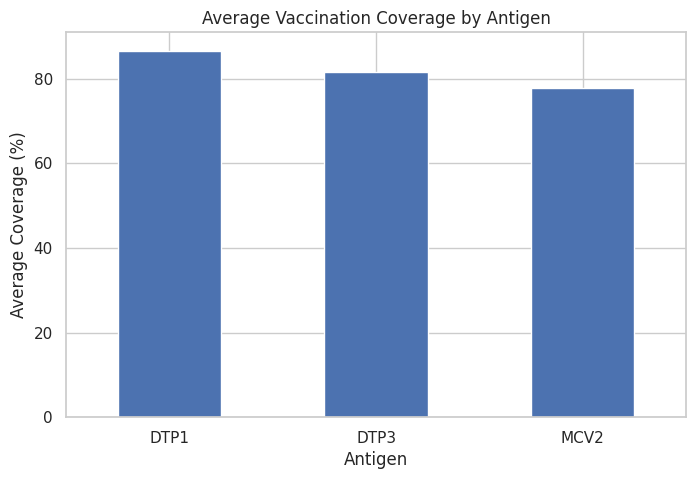

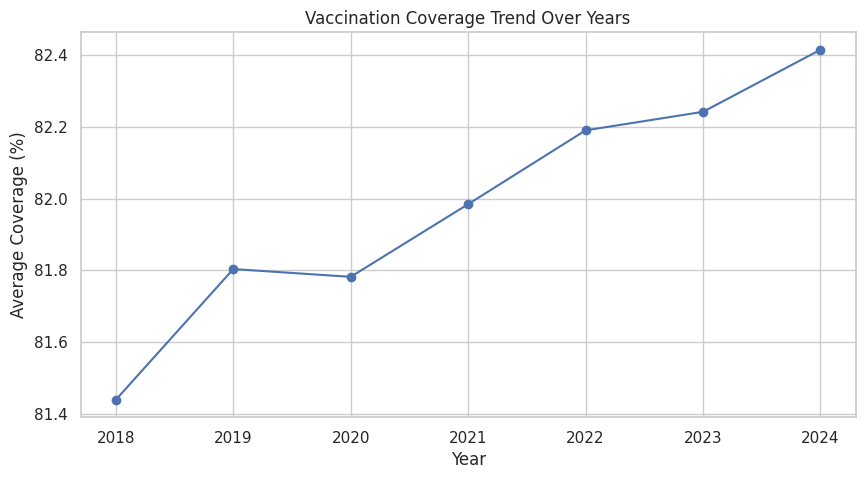

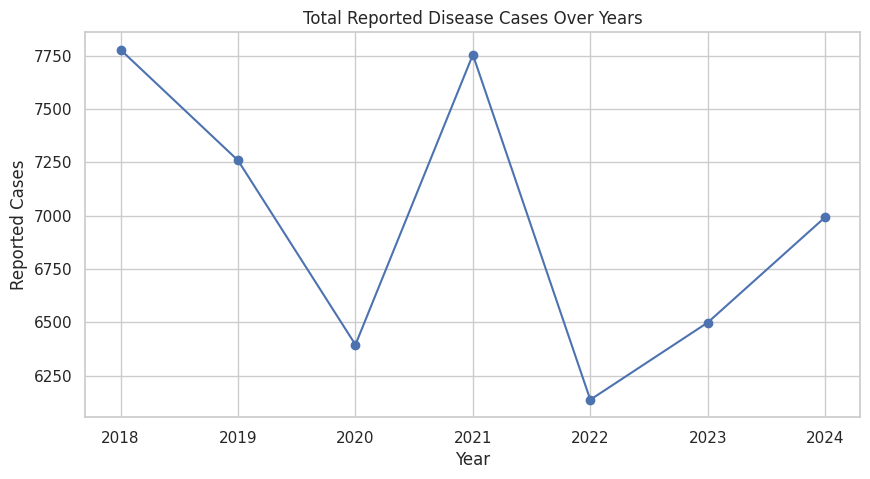

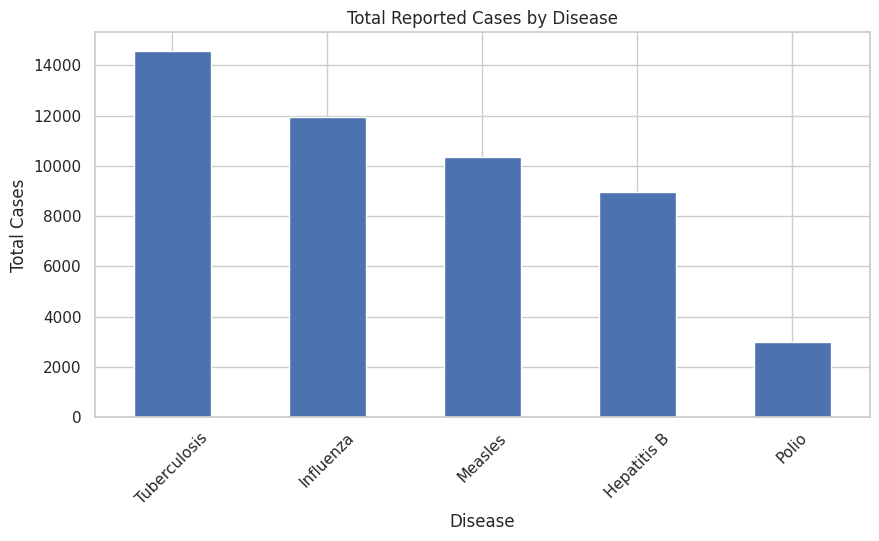

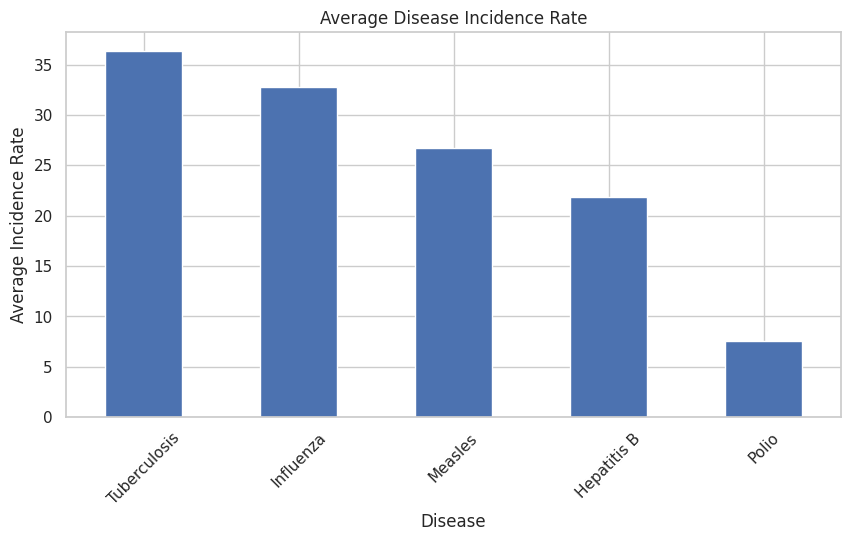

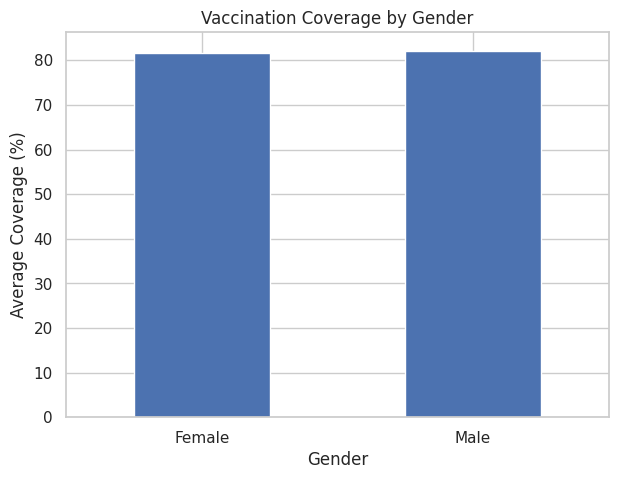

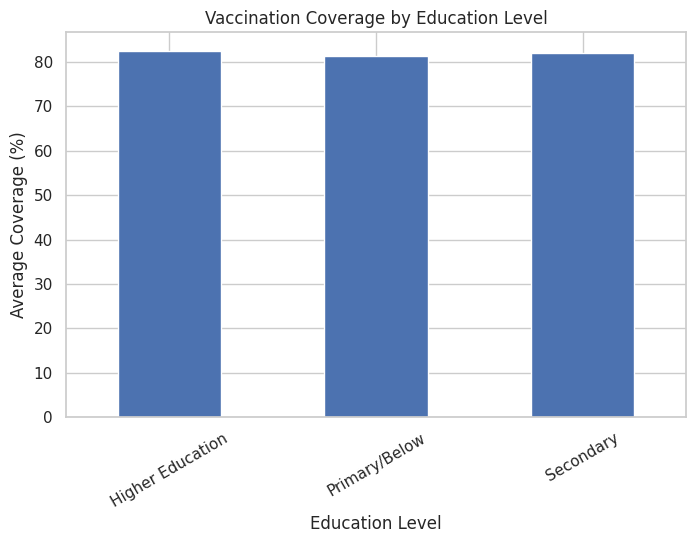

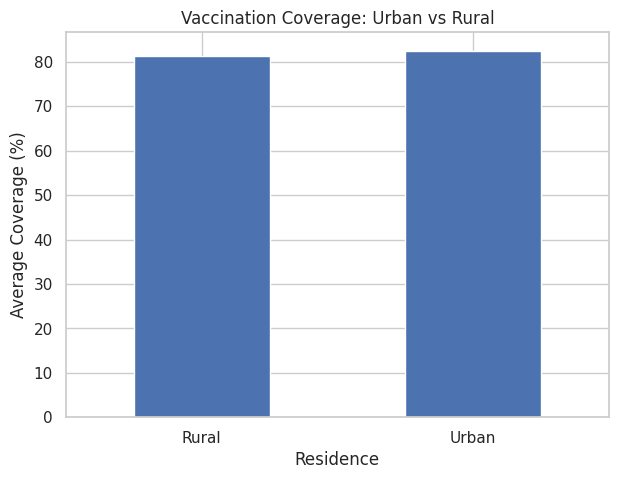

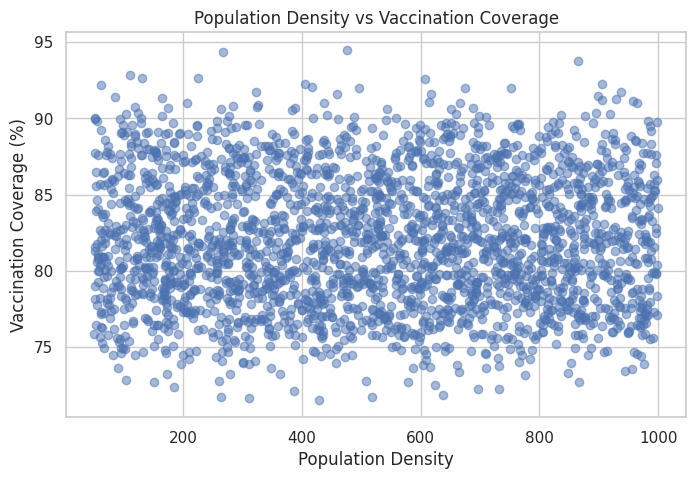

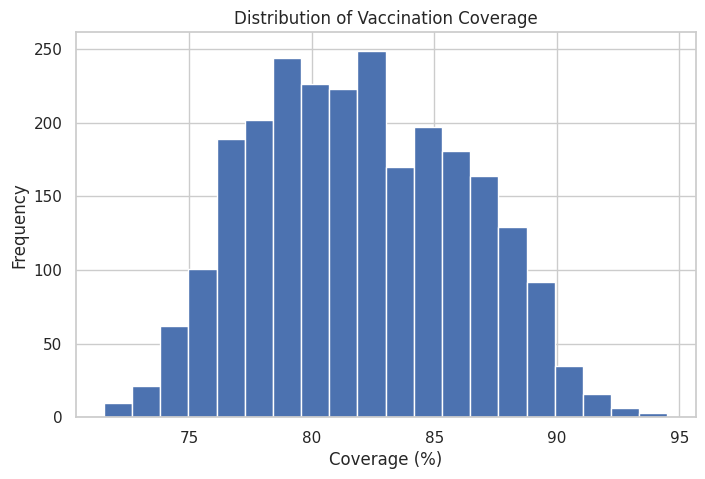

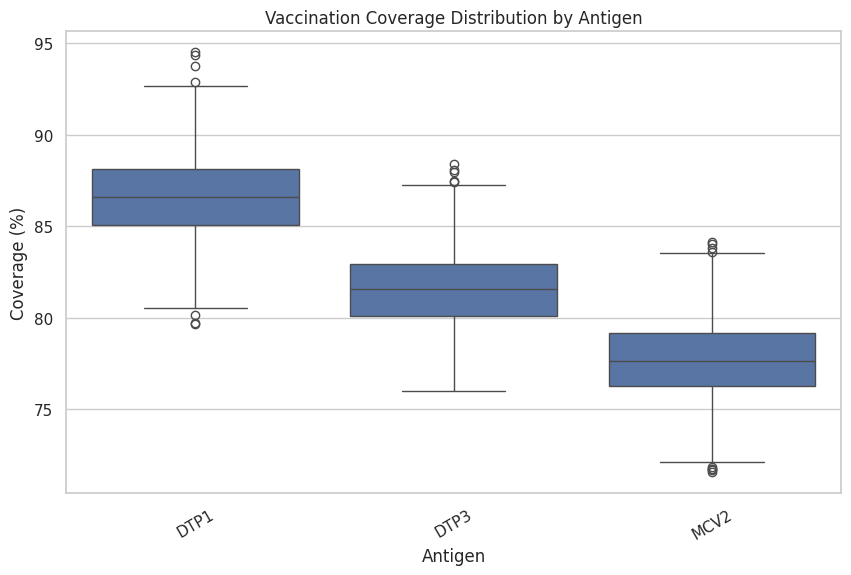

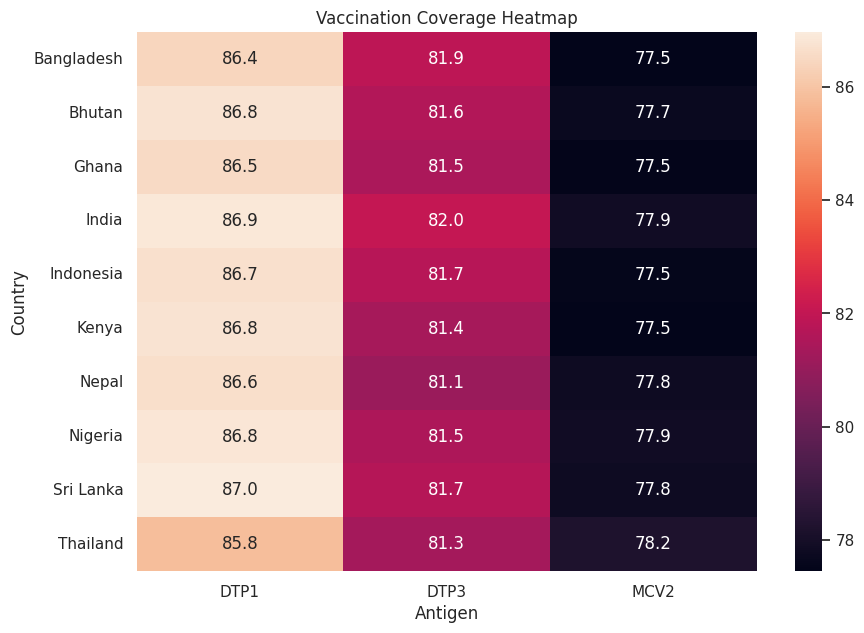

ALL EDA VISUALIZATIONS COMPLETED! ✅


In [ ]:
# ============================================================
# STEP 2C — EDA VISUALIZATIONS
# ============================================================

sns.set_theme(style="whitegrid")


# ------------------------------------------------------------
# GRAPH 1 — COVERAGE BY ANTIGEN
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

average_coverage.plot(kind="bar")

plt.title("Average Vaccination Coverage by Antigen")
plt.xlabel("Antigen")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=0)

plt.show()


# ------------------------------------------------------------
# GRAPH 2 — COVERAGE TREND
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(
    yearly_coverage.index,
    yearly_coverage.values,
    marker="o"
)

plt.title("Vaccination Coverage Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average Coverage (%)")
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# GRAPH 3 — REPORTED CASES TREND
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(
    yearly_cases.index,
    yearly_cases.values,
    marker="o"
)

plt.title("Total Reported Disease Cases Over Years")
plt.xlabel("Year")
plt.ylabel("Reported Cases")
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# GRAPH 4 — CASES BY DISEASE
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

disease_cases.plot(kind="bar")

plt.title("Total Reported Cases by Disease")
plt.xlabel("Disease")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)

plt.show()


# ------------------------------------------------------------
# GRAPH 5 — INCIDENCE BY DISEASE
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

disease_incidence.plot(kind="bar")

plt.title("Average Disease Incidence Rate")
plt.xlabel("Disease")
plt.ylabel("Average Incidence Rate")
plt.xticks(rotation=45)

plt.show()


# ------------------------------------------------------------
# GRAPH 6 — GENDER
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

gender_coverage.plot(kind="bar")

plt.title("Vaccination Coverage by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=0)

plt.show()


# ------------------------------------------------------------
# GRAPH 7 — EDUCATION
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

education_coverage.plot(kind="bar")

plt.title("Vaccination Coverage by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=30)

plt.show()


# ------------------------------------------------------------
# GRAPH 8 — URBAN VS RURAL
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

residence_coverage.plot(kind="bar")

plt.title("Vaccination Coverage: Urban vs Rural")
plt.xlabel("Residence")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=0)

plt.show()


# ------------------------------------------------------------
# GRAPH 9 — POPULATION DENSITY VS COVERAGE
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.scatter(
    coverage["population_density"],
    coverage["coverage"],
    alpha=0.5
)

plt.title("Population Density vs Vaccination Coverage")
plt.xlabel("Population Density")
plt.ylabel("Vaccination Coverage (%)")

plt.show()


# ------------------------------------------------------------
# GRAPH 10 — COVERAGE DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.hist(
    coverage["coverage"],
    bins=20
)

plt.title("Distribution of Vaccination Coverage")
plt.xlabel("Coverage (%)")
plt.ylabel("Frequency")

plt.show()


# ------------------------------------------------------------
# GRAPH 11 — COVERAGE BOXPLOT
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

sns.boxplot(
    data=coverage,
    x="antigen",
    y="coverage"
)

plt.title("Vaccination Coverage Distribution by Antigen")
plt.xlabel("Antigen")
plt.ylabel("Coverage (%)")
plt.xticks(rotation=30)

plt.show()


# ------------------------------------------------------------
# GRAPH 12 — COVERAGE HEATMAP
# ------------------------------------------------------------

heatmap_data = coverage.pivot_table(
    index="country",
    columns="antigen",
    values="coverage",
    aggfunc="mean"
)

plt.figure(figsize=(10,7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title("Vaccination Coverage Heatmap")
plt.xlabel("Antigen")
plt.ylabel("Country")

plt.show()


print("=" * 60)
print("ALL EDA VISUALIZATIONS COMPLETED! ✅")
print("=" * 60)

In [ ]:
# ============================================================
# STEP 2D — SAVE CLEANED DATA
# ============================================================

coverage.to_csv(
    "cleaned_coverage.csv",
    index=False
)

incidence.to_csv(
    "cleaned_incidence_rate.csv",
    index=False
)

reported_cases.to_csv(
    "cleaned_reported_cases.csv",
    index=False
)

vaccine_intro.to_csv(
    "cleaned_vaccine_introduction.csv",
    index=False
)

vaccine_schedule.to_csv(
    "cleaned_vaccine_schedule.csv",
    index=False
)

print("Cleaned files created successfully:")
print("✓ cleaned_coverage.csv")
print("✓ cleaned_incidence_rate.csv")
print("✓ cleaned_reported_cases.csv")
print("✓ cleaned_vaccine_introduction.csv")
print("✓ cleaned_vaccine_schedule.csv")

print("\nSTEP 2 — CLEANING + EDA COMPLETED! 🎉")

Cleaned files created successfully:
✓ cleaned_coverage.csv
✓ cleaned_incidence_rate.csv
✓ cleaned_reported_cases.csv
✓ cleaned_vaccine_introduction.csv
✓ cleaned_vaccine_schedule.csv

STEP 2 — CLEANING + EDA COMPLETED! 🎉


QUESTION 1
Does higher vaccination coverage relate to lower disease incidence?

Correlation: -0.525
Answer: The data shows a strong negative association. Higher vaccination coverage is associated with lower disease incidence.


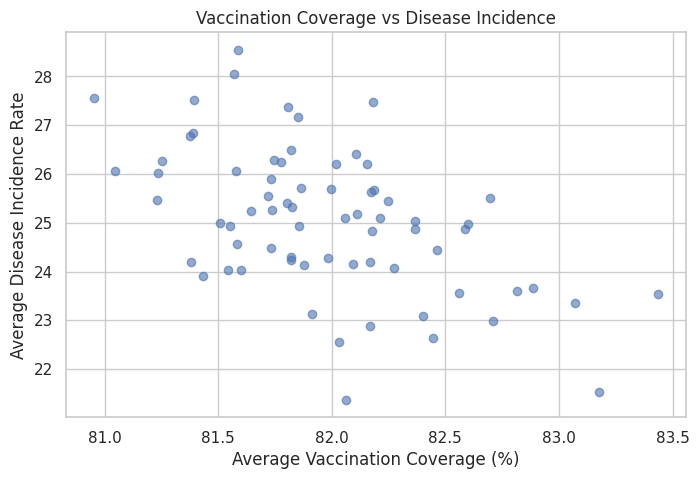

In [ ]:
# ============================================================
# QUESTION 1
# Vaccination Coverage vs Disease Incidence
# ============================================================

print("=" * 70)
print("QUESTION 1")
print("Does higher vaccination coverage relate to lower disease incidence?")
print("=" * 70)

# Calculate average vaccination coverage by country and year
coverage_q1 = (
    coverage
    .groupby(["country", "year"])["coverage"]
    .mean()
    .reset_index()
)

# Calculate average incidence by country and year
incidence_q1 = (
    incidence
    .groupby(["country", "year"])["incidence_rate"]
    .mean()
    .reset_index()
)

# Merge both datasets
q1_data = pd.merge(
    coverage_q1,
    incidence_q1,
    on=["country", "year"],
    how="inner"
)

# Calculate correlation
q1_correlation = q1_data["coverage"].corr(
    q1_data["incidence_rate"]
)

print("\nCorrelation:", round(q1_correlation, 3))

# Interpretation
if q1_correlation < -0.5:
    print(
        "Answer: The data shows a strong negative association. "
        "Higher vaccination coverage is associated with lower disease incidence."
    )
elif q1_correlation < 0:
    print(
        "Answer: The data shows a negative association between "
        "vaccination coverage and disease incidence."
    )
else:
    print(
        "Answer: The data does not show a negative association "
        "between vaccination coverage and disease incidence."
    )

# Visualization
plt.figure(figsize=(8, 5))

plt.scatter(
    q1_data["coverage"],
    q1_data["incidence_rate"],
    alpha=0.6
)

plt.title("Vaccination Coverage vs Disease Incidence")
plt.xlabel("Average Vaccination Coverage (%)")
plt.ylabel("Average Disease Incidence Rate")

plt.show()

QUESTION 2
What is the drop-off between the first and subsequent doses?

Average coverage:


,coverage
antigen,
DTP1,86.63
DTP3,81.59
MCV2,77.72



DTP1 coverage: 86.63 %
DTP3 coverage: 81.59 %
MCV2 coverage: 77.72 %

DTP1 → DTP3 drop: 5.04 percentage points
DTP1 → MCV2 drop: 8.9 percentage points


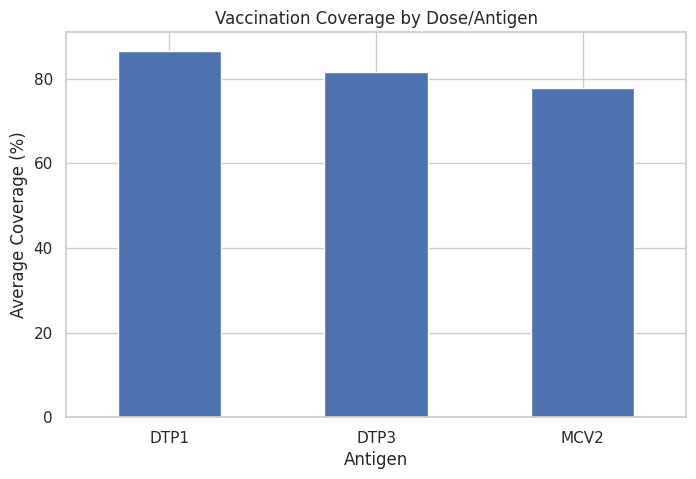

In [ ]:
# ============================================================
# QUESTION 2
# Drop-off Between First and Subsequent Doses
# ============================================================

print("=" * 70)
print("QUESTION 2")
print("What is the drop-off between the first and subsequent doses?")
print("=" * 70)

# Calculate average coverage for each antigen
dose_coverage = (
    coverage[
        coverage["antigen"].isin(["DTP1", "DTP3", "MCV2"])
    ]
    .groupby("antigen")["coverage"]
    .mean()
)

print("\nAverage coverage:")
display(dose_coverage.round(2))

# Get values
dtp1 = dose_coverage.get("DTP1")
dtp3 = dose_coverage.get("DTP3")
mcv2 = dose_coverage.get("MCV2")

# Calculate drop-off
dtp1_dtp3_drop = dtp1 - dtp3
dtp1_mcv2_drop = dtp1 - mcv2

print("\nDTP1 coverage:", round(dtp1, 2), "%")
print("DTP3 coverage:", round(dtp3, 2), "%")
print("MCV2 coverage:", round(mcv2, 2), "%")

print(
    "\nDTP1 → DTP3 drop:",
    round(dtp1_dtp3_drop, 2),
    "percentage points"
)

print(
    "DTP1 → MCV2 drop:",
    round(dtp1_mcv2_drop, 2),
    "percentage points"
)

# Visualization
plt.figure(figsize=(8, 5))

dose_coverage.plot(kind="bar")

plt.title("Vaccination Coverage by Dose/Antigen")
plt.xlabel("Antigen")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=0)

plt.show()

QUESTION 3
Is there a difference in vaccination coverage between males and females?

Average vaccination coverage by gender:


,coverage
gender,
Male,82.20
Female,81.76



Difference: 0.44 percentage points


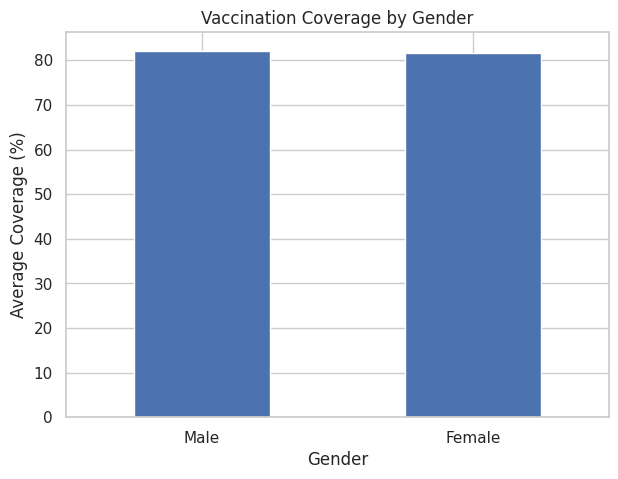

In [ ]:
# ============================================================
# QUESTION 3
# Gender Difference in Vaccination Coverage
# ============================================================

print("=" * 70)
print("QUESTION 3")
print("Is there a difference in vaccination coverage between males and females?")
print("=" * 70)

gender_result = (
    coverage
    .groupby("gender")["coverage"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage vaccination coverage by gender:")
display(gender_result.round(2))

# Calculate difference
male_coverage = gender_result.get("Male")
female_coverage = gender_result.get("Female")

gender_difference = abs(
    male_coverage - female_coverage
)

print(
    "\nDifference:",
    round(gender_difference, 2),
    "percentage points"
)

# Visualization
plt.figure(figsize=(7, 5))

gender_result.plot(kind="bar")

plt.title("Vaccination Coverage by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=0)

plt.show()

QUESTION 4
Does education level affect vaccination coverage?

Average coverage by education level:


,coverage
education_level,
Higher Education,82.55
Secondary,82.09
Primary/Below,81.30



Highest average coverage: Higher Education = 82.55 %
Lowest average coverage: Primary/Below = 81.3 %

Difference between highest and lowest: 1.26 percentage points


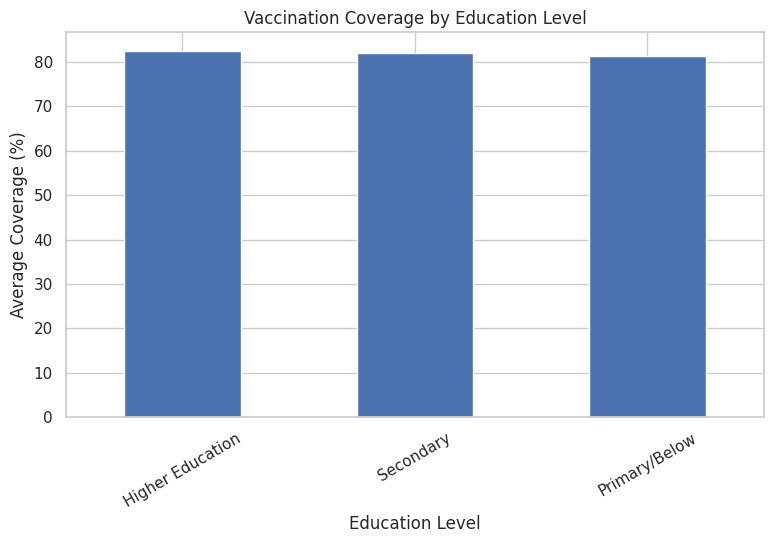

In [ ]:
# ============================================================
# QUESTION 4
# Education Level and Vaccination Coverage
# ============================================================

print("=" * 70)
print("QUESTION 4")
print("Does education level affect vaccination coverage?")
print("=" * 70)

education_result = (
    coverage
    .groupby("education_level")["coverage"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage coverage by education level:")
display(education_result.round(2))

# Highest and lowest
highest_education = education_result.idxmax()
lowest_education = education_result.idxmin()

print(
    "\nHighest average coverage:",
    highest_education,
    "=",
    round(education_result.max(), 2),
    "%"
)

print(
    "Lowest average coverage:",
    lowest_education,
    "=",
    round(education_result.min(), 2),
    "%"
)

# Difference
education_difference = (
    education_result.max() -
    education_result.min()
)

print(
    "\nDifference between highest and lowest:",
    round(education_difference, 2),
    "percentage points"
)

# Visualization
plt.figure(figsize=(9, 5))

education_result.plot(kind="bar")

plt.title("Vaccination Coverage by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=30)

plt.show()

QUESTION 5
Is vaccination coverage different between urban and rural populations?

Average vaccination coverage:


,coverage
residence,
Urban,82.56
Rural,81.40



Urban coverage: 82.56 %
Rural coverage: 81.4 %
Difference: 1.16 percentage points


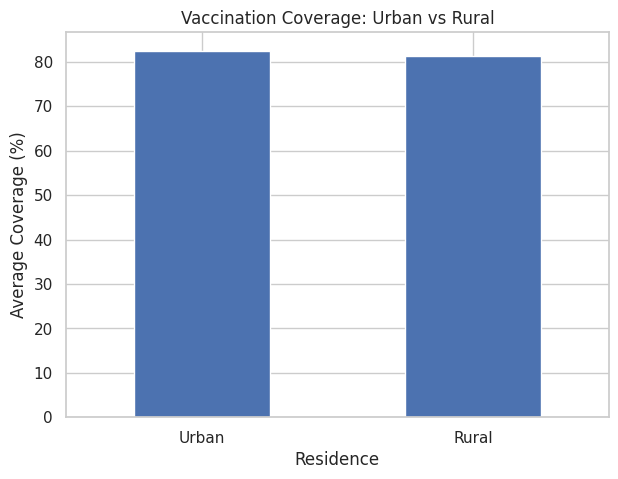

In [ ]:
# ============================================================
# QUESTION 5
# Urban vs Rural Vaccination Coverage
# ============================================================

print("=" * 70)
print("QUESTION 5")
print("Is vaccination coverage different between urban and rural populations?")
print("=" * 70)

residence_result = (
    coverage
    .groupby("residence")["coverage"]
    .mean()
    .sort_values(ascending=False)
)

print("\nAverage vaccination coverage:")
display(residence_result.round(2))

# Get values
urban = residence_result.get("Urban")
rural = residence_result.get("Rural")

difference = abs(urban - rural)

print("\nUrban coverage:", round(urban, 2), "%")
print("Rural coverage:", round(rural, 2), "%")

print(
    "Difference:",
    round(difference, 2),
    "percentage points"
)

# Visualization
plt.figure(figsize=(7, 5))

residence_result.plot(kind="bar")

plt.title("Vaccination Coverage: Urban vs Rural")
plt.xlabel("Residence")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=0)

plt.show()

QUESTION 6
Are subsequent-dose vaccination records increasing over time?


,0
year,
2018,240
2019,240
2020,240
2021,240
2022,240
2023,240
2024,240


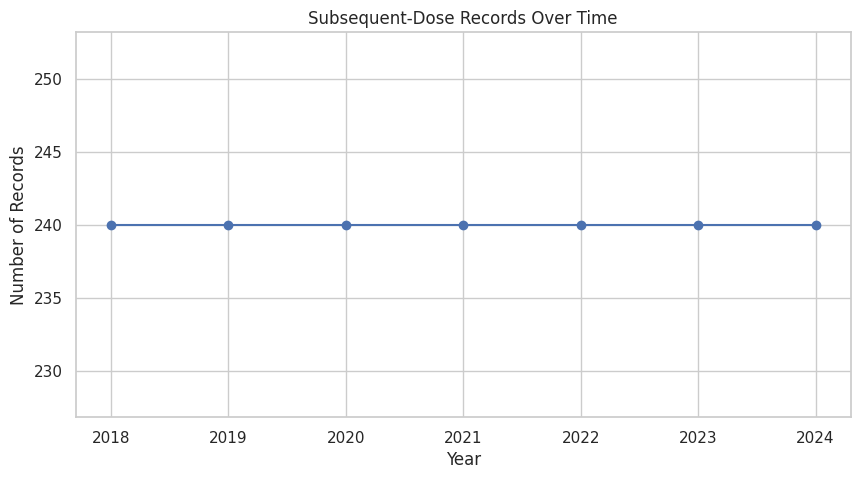


Note: This measures the number of records in this dataset, not direct population-level booster uptake.

QUESTION 7
Is there a seasonal pattern in vaccination coverage?


,coverage
month,
1,81.94
2,82.11
3,81.72
4,82.24
5,81.86
6,81.90
7,82.37
8,81.86
9,82.09



Difference between highest and lowest month: 0.65 percentage points


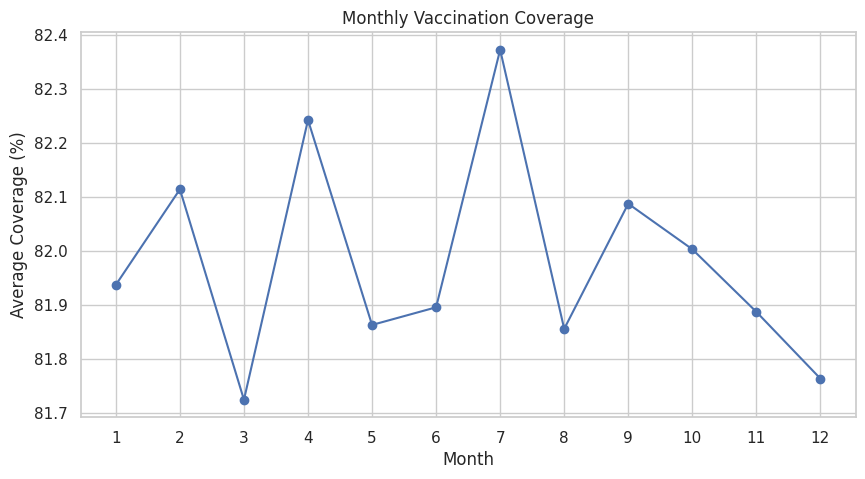


QUESTION 8
Is population density related to vaccination coverage?
Correlation between population density and vaccination coverage: -0.004


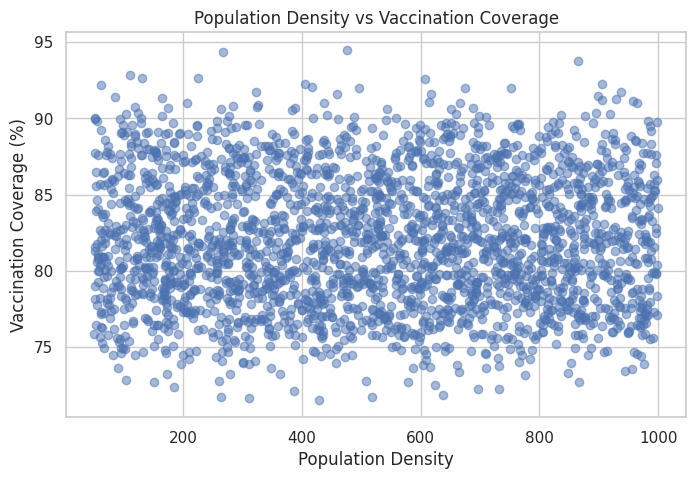


QUESTION 9
What is the relationship between vaccination coverage and disease incidence?
Correlation: -0.525
Interpretation: The relationship is negative; higher vaccination coverage is associated with lower incidence.


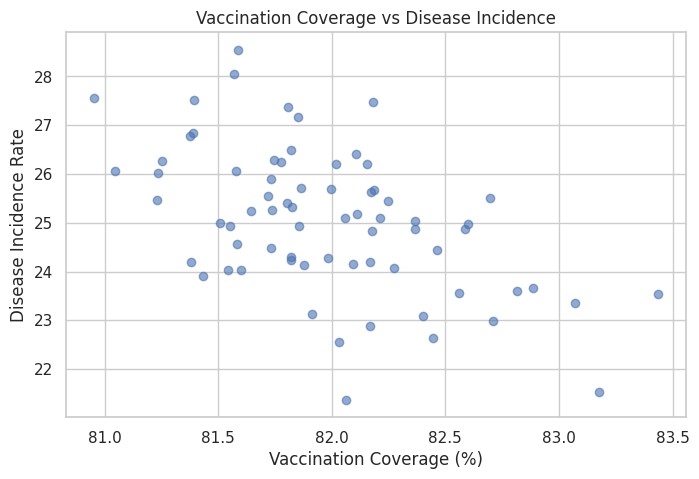


QUESTION 10
Are there countries with high vaccination coverage but high disease incidence?
High coverage threshold: 82.07
High incidence threshold: 25.34

Countries with both high coverage and high incidence:
No countries meet both thresholds in this synthetic dataset.


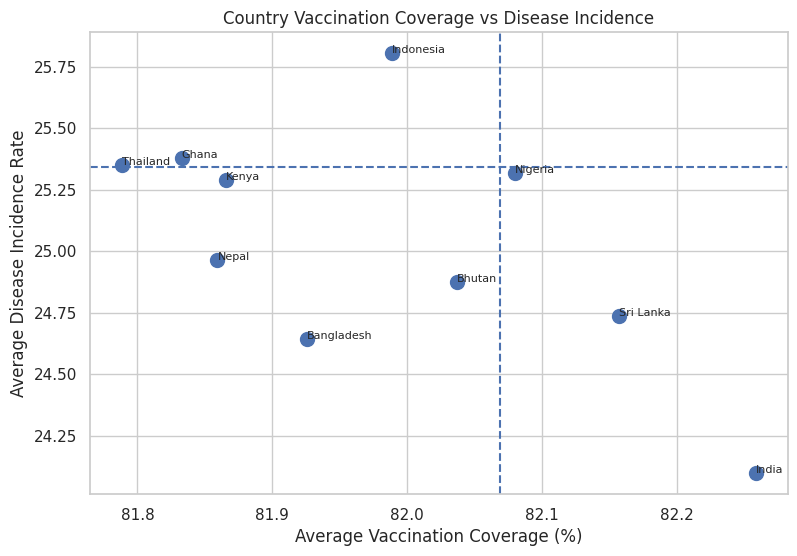


ALL 10 EASY QUESTIONS COMPLETED! ✅


In [ ]:
# ============================================================
# QUESTION 6
# Are subsequent-dose / booster vaccination records increasing?
# ============================================================

print("=" * 70)
print("QUESTION 6")
print("Are subsequent-dose vaccination records increasing over time?")
print("=" * 70)

subsequent_doses = coverage[
    coverage["antigen"].isin(["DTP3", "MCV2"])
]

subsequent_by_year = (
    subsequent_doses
    .groupby("year")
    .size()
)

display(subsequent_by_year)

plt.figure(figsize=(10, 5))

plt.plot(
    subsequent_by_year.index,
    subsequent_by_year.values,
    marker="o"
)

plt.title("Subsequent-Dose Records Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Records")
plt.grid(True)

plt.show()

print(
    "\nNote: This measures the number of records in this dataset, "
    "not direct population-level booster uptake."
)


# ============================================================
# QUESTION 7
# Is there a seasonal pattern in vaccination coverage?
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 7")
print("Is there a seasonal pattern in vaccination coverage?")
print("=" * 70)

monthly_coverage = (
    coverage
    .groupby("month")["coverage"]
    .mean()
)

display(monthly_coverage.round(2))

seasonal_difference = (
    monthly_coverage.max() -
    monthly_coverage.min()
)

print(
    "\nDifference between highest and lowest month:",
    round(seasonal_difference, 2),
    "percentage points"
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_coverage.index,
    monthly_coverage.values,
    marker="o"
)

plt.title("Monthly Vaccination Coverage")
plt.xlabel("Month")
plt.ylabel("Average Coverage (%)")
plt.xticks(range(1, 13))
plt.grid(True)

plt.show()


# ============================================================
# QUESTION 8
# Is population density related to vaccination coverage?
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 8")
print("Is population density related to vaccination coverage?")
print("=" * 70)

density_correlation = (
    coverage["population_density"]
    .corr(coverage["coverage"])
)

print(
    "Correlation between population density and vaccination coverage:",
    round(density_correlation, 3)
)

plt.figure(figsize=(8, 5))

plt.scatter(
    coverage["population_density"],
    coverage["coverage"],
    alpha=0.5
)

plt.title("Population Density vs Vaccination Coverage")
plt.xlabel("Population Density")
plt.ylabel("Vaccination Coverage (%)")

plt.show()


# ============================================================
# QUESTION 9
# What is the relationship between vaccination coverage
# and disease incidence?
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 9")
print("What is the relationship between vaccination coverage and disease incidence?")
print("=" * 70)

# Average coverage by country/year
q9_coverage = (
    coverage
    .groupby(["country", "year"])["coverage"]
    .mean()
    .reset_index()
)

# Average incidence by country/year
q9_incidence = (
    incidence
    .groupby(["country", "year"])["incidence_rate"]
    .mean()
    .reset_index()
)

# Merge
q9_data = pd.merge(
    q9_coverage,
    q9_incidence,
    on=["country", "year"],
    how="inner"
)

# Correlation
q9_correlation = (
    q9_data["coverage"]
    .corr(q9_data["incidence_rate"])
)

print(
    "Correlation:",
    round(q9_correlation, 3)
)

if q9_correlation < 0:
    print(
        "Interpretation: The relationship is negative; "
        "higher vaccination coverage is associated with lower incidence."
    )
else:
    print(
        "Interpretation: The relationship is not negative "
        "in this dataset."
    )

plt.figure(figsize=(8, 5))

plt.scatter(
    q9_data["coverage"],
    q9_data["incidence_rate"],
    alpha=0.6
)

plt.title("Vaccination Coverage vs Disease Incidence")
plt.xlabel("Vaccination Coverage (%)")
plt.ylabel("Disease Incidence Rate")

plt.show()


# ============================================================
# QUESTION 10
# Are there regions/countries with high vaccination coverage
# but also high disease incidence?
# ============================================================

print("\n" + "=" * 70)
print("QUESTION 10")
print("Are there countries with high vaccination coverage but high disease incidence?")
print("=" * 70)


# Country-level average coverage
country_avg_coverage = (
    coverage
    .groupby("country")["coverage"]
    .mean()
    .reset_index()
)

country_avg_coverage.columns = [
    "country",
    "average_coverage"
]


# Country-level average incidence
country_avg_incidence = (
    incidence
    .groupby("country")["incidence_rate"]
    .mean()
    .reset_index()
)

country_avg_incidence.columns = [
    "country",
    "average_incidence"
]


# Merge
country_risk = pd.merge(
    country_avg_coverage,
    country_avg_incidence,
    on="country"
)


# Calculate top quartile thresholds
coverage_threshold = (
    country_risk["average_coverage"]
    .quantile(0.75)
)

incidence_threshold = (
    country_risk["average_incidence"]
    .quantile(0.75)
)


print(
    "High coverage threshold:",
    round(coverage_threshold, 2)
)

print(
    "High incidence threshold:",
    round(incidence_threshold, 2)
)


# Find countries satisfying both
high_coverage_high_incidence = country_risk[
    (country_risk["average_coverage"] >= coverage_threshold) &
    (country_risk["average_incidence"] >= incidence_threshold)
]


print("\nCountries with both high coverage and high incidence:")

if len(high_coverage_high_incidence) == 0:

    print(
        "No countries meet both thresholds in this synthetic dataset."
    )

else:

    display(
        high_coverage_high_incidence
        .sort_values(
            "average_incidence",
            ascending=False
        )
    )


# Visualization
plt.figure(figsize=(9, 6))

plt.scatter(
    country_risk["average_coverage"],
    country_risk["average_incidence"],
    s=100
)

# Add country labels
for _, row in country_risk.iterrows():

    plt.annotate(
        row["country"],
        (
            row["average_coverage"],
            row["average_incidence"]
        ),
        fontsize=8
    )

plt.axvline(
    coverage_threshold,
    linestyle="--"
)

plt.axhline(
    incidence_threshold,
    linestyle="--"
)

plt.title(
    "Country Vaccination Coverage vs Disease Incidence"
)

plt.xlabel("Average Vaccination Coverage (%)")
plt.ylabel("Average Disease Incidence Rate")

plt.show()


print("\n" + "=" * 70)
print("ALL 10 EASY QUESTIONS COMPLETED! ✅")
print("=" * 70)

Correlation: nan


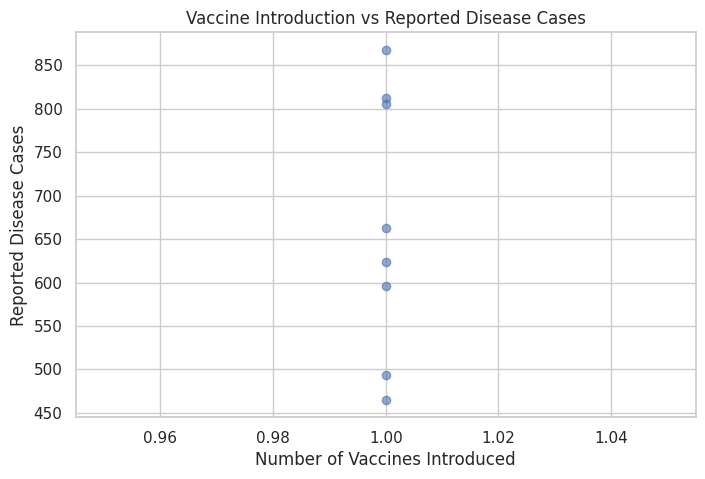

In [ ]:
# ============================================================
# MEDIUM Q1
# Vaccine Introduction vs Reported Disease Cases
# ============================================================

intro_q1 = vaccine_intro.groupby(
    ["country", "year"]
).size().reset_index(name="vaccines_introduced")

cases_q1 = reported_cases.groupby(
    ["country", "year"]
)["cases"].sum().reset_index()

q1_medium = pd.merge(
    intro_q1,
    cases_q1,
    on=["country", "year"],
    how="inner"
)

correlation = q1_medium["vaccines_introduced"].corr(
    q1_medium["cases"]
)

print("Correlation:", round(correlation, 3))

plt.figure(figsize=(8,5))
plt.scatter(
    q1_medium["vaccines_introduced"],
    q1_medium["cases"],
    alpha=0.6
)
plt.title("Vaccine Introduction vs Reported Disease Cases")
plt.xlabel("Number of Vaccines Introduced")
plt.ylabel("Reported Disease Cases")
plt.show()

period
After Introduction    25.045171
Name: incidence_rate, dtype: float64


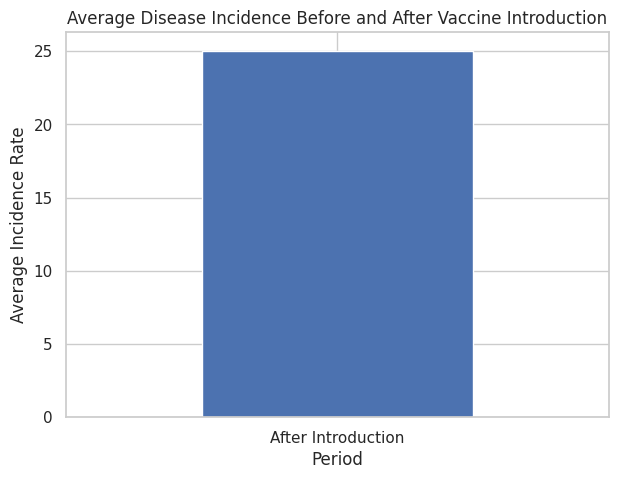

In [ ]:
# ============================================================
# MEDIUM Q2
# Before vs After Vaccine Introduction
# ============================================================

intro_years = vaccine_intro.groupby(
    "country"
)["year"].min().reset_index()

intro_years.rename(
    columns={"year": "first_introduction_year"},
    inplace=True
)

q2_medium = pd.merge(
    incidence,
    intro_years,
    on="country",
    how="left"
)

q2_medium["period"] = np.where(
    q2_medium["year"] < q2_medium["first_introduction_year"],
    "Before Introduction",
    "After Introduction"
)

comparison = q2_medium.groupby(
    "period"
)["incidence_rate"].mean()

print(comparison)

plt.figure(figsize=(7,5))
comparison.plot(kind="bar")
plt.title("Average Disease Incidence Before and After Vaccine Introduction")
plt.xlabel("Period")
plt.ylabel("Average Incidence Rate")
plt.xticks(rotation=0)
plt.show()

              Start_Incidence  End_Incidence  Reduction  Reduction_%
disease                                                             
Polio                   7.454          6.533      0.921    12.355782
Tuberculosis           38.116         34.094      4.022    10.551999
Influenza              32.562         32.028      0.534     1.639948
Measles                27.198         26.885      0.313     1.150820
Hepatitis B            21.570         23.010     -1.440    -6.675939


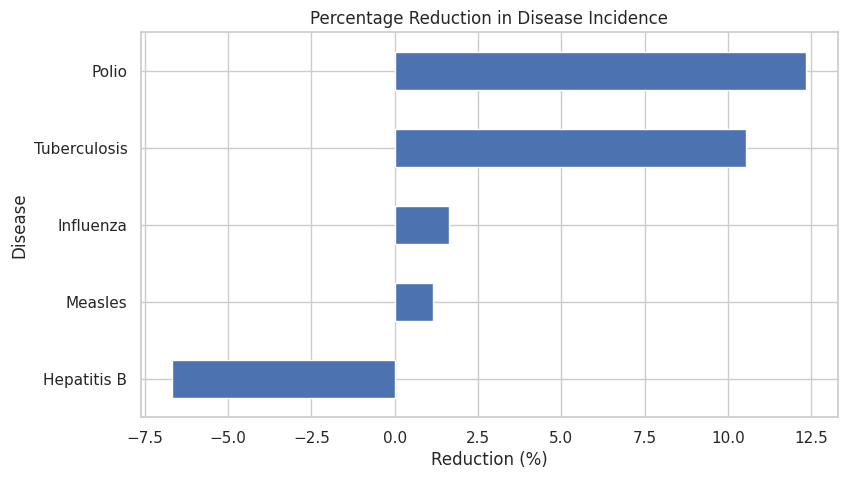

In [ ]:
# ============================================================
# MEDIUM Q3
# Disease Reduction Over Time
# ============================================================

start_incidence = incidence[
    incidence["year"] == incidence["year"].min()
].groupby("disease")["incidence_rate"].mean()

end_incidence = incidence[
    incidence["year"] == incidence["year"].max()
].groupby("disease")["incidence_rate"].mean()

q3_medium = pd.DataFrame({
    "Start_Incidence": start_incidence,
    "End_Incidence": end_incidence
})

q3_medium["Reduction"] = (
    q3_medium["Start_Incidence"]
    - q3_medium["End_Incidence"]
)

q3_medium["Reduction_%"] = (
    q3_medium["Reduction"]
    / q3_medium["Start_Incidence"]
) * 100

print(q3_medium.sort_values(
    "Reduction_%",
    ascending=False
))

plt.figure(figsize=(9,5))
q3_medium["Reduction_%"].sort_values().plot(
    kind="barh"
)
plt.title("Percentage Reduction in Disease Incidence")
plt.xlabel("Reduction (%)")
plt.ylabel("Disease")
plt.show()

      country  year antigen  target_population  vaccinated_population  \
0  Bangladesh  2018    DTP1            3257200                2806838   
1  Bangladesh  2018    DTP3            3916161                3218128   
2  Bangladesh  2018    MCV2            2878087                2230737   
3  Bangladesh  2019    DTP1            2679286                2321994   
4  Bangladesh  2019    DTP3            3638028                2968624   
5  Bangladesh  2019    MCV2            3887060                3000809   
6  Bangladesh  2020    DTP1            3230403                2778559   
7  Bangladesh  2020    DTP3            3493976                2828465   
8  Bangladesh  2020    MCV2            3126927                2412818   
9  Bangladesh  2021    DTP1            3171457                2766502   

   coverage_calculated  
0            86.173339  
1            82.175580  
2            77.507629  
3            86.664656  
4            81.599812  
5            77.199966  
6            86.01276

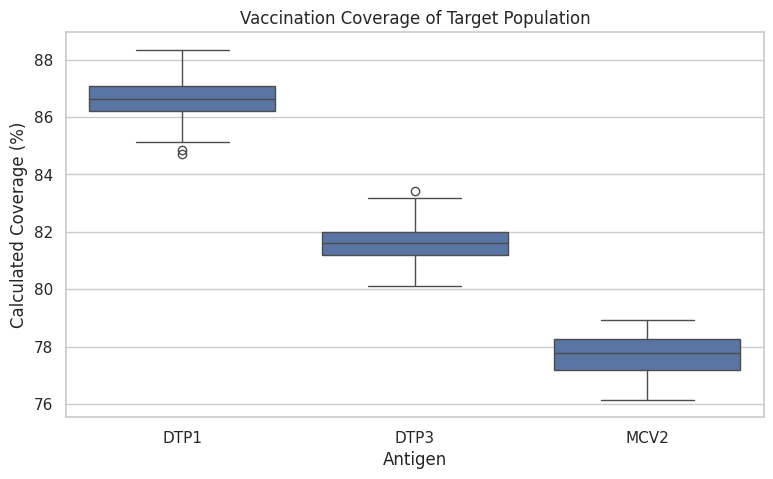

In [ ]:
# ============================================================
# MEDIUM Q4
# Target Population vs Vaccinated Population
# ============================================================

q4_medium = coverage.groupby(
    ["country", "year", "antigen"]
).agg(
    target_population=("target_number", "sum"),
    vaccinated_population=("doses", "sum")
).reset_index()

q4_medium["coverage_calculated"] = (
    q4_medium["vaccinated_population"]
    / q4_medium["target_population"]
) * 100

print(q4_medium.head(10))

print(
    "\nOverall target population coverage:",
    round(q4_medium["coverage_calculated"].mean(), 2),
    "%"
)

plt.figure(figsize=(9,5))
sns.boxplot(
    data=q4_medium,
    x="antigen",
    y="coverage_calculated"
)
plt.title("Vaccination Coverage of Target Population")
plt.xlabel("Antigen")
plt.ylabel("Calculated Coverage (%)")
plt.show()

Average Schedule Rounds:
  vaccine_code  schedule_rounds
0          DTP              1.9
1  Hepatitis B              2.1
2    Influenza              1.8
3          MCV              2.3
4        Polio              2.1

Average Coverage:
  antigen   coverage
0    DTP1  86.627643
1    DTP3  81.585857
2    MCV2  77.724179


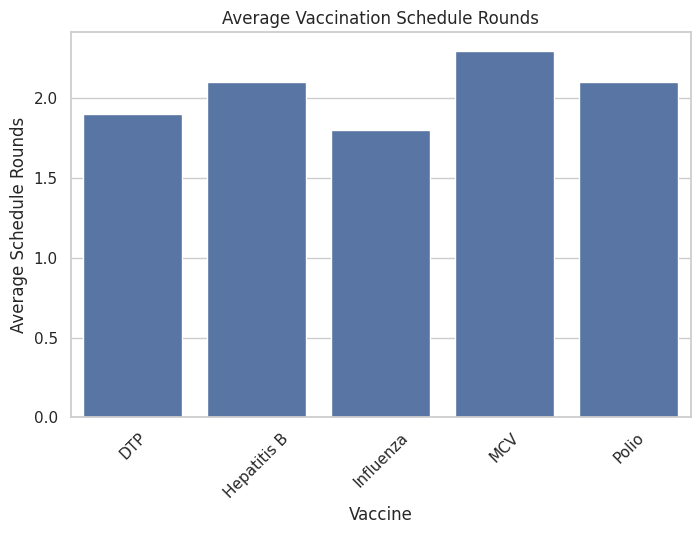

In [ ]:
# ============================================================
# MEDIUM Q5
# Schedule Rounds vs Coverage
# ============================================================

schedule_avg = vaccine_schedule.groupby(
    "vaccine_code"
)["schedule_rounds"].mean().reset_index()

coverage_avg = coverage.groupby(
    "antigen"
)["coverage"].mean().reset_index()

print("Average Schedule Rounds:")
print(schedule_avg)

print("\nAverage Coverage:")
print(coverage_avg)

plt.figure(figsize=(8,5))
sns.barplot(
    data=schedule_avg,
    x="vaccine_code",
    y="schedule_rounds"
)
plt.title("Average Vaccination Schedule Rounds")
plt.xlabel("Vaccine")
plt.ylabel("Average Schedule Rounds")
plt.xticks(rotation=45)
plt.show()

   WHO_region  year  number_of_introductions
0        AFRO  2011                        1
1        AFRO  2012                        2
2        AFRO  2017                        1
3        AFRO  2019                        1
4        EMRO  2010                        3
5        EMRO  2011                        4
6        EMRO  2012                        6
7        EMRO  2014                        6
8        EMRO  2015                        2
9        EMRO  2016                        3
10       EMRO  2017                        3
11       EMRO  2018                        1
12       EMRO  2019                        1
13       EMRO  2020                        1
14      SEARO  2015                        1
15      SEARO  2016                        1
16      SEARO  2017                        1
17      SEARO  2018                        1
18      SEARO  2019                        1
19       WPRO  2010                        1
20       WPRO  2012                        2
21       W

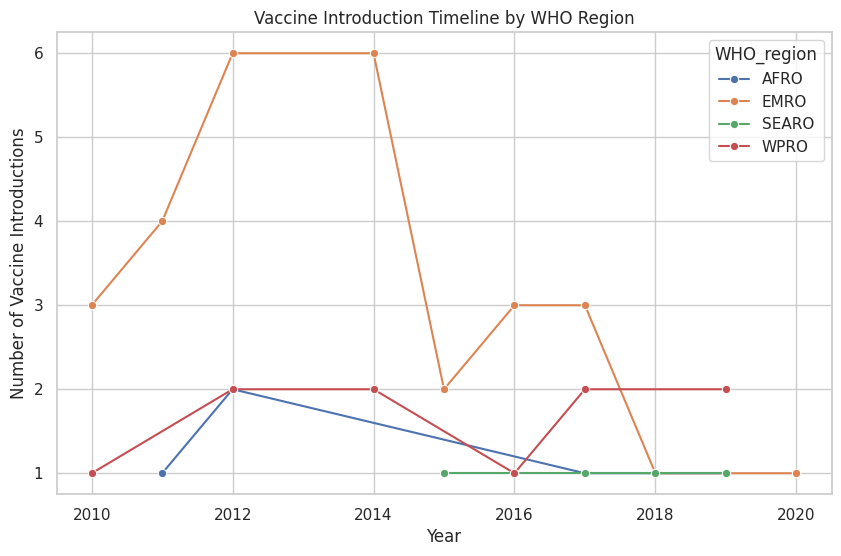

In [ ]:
# ============================================================
# MEDIUM Q6
# Vaccine Introduction Timeline by WHO Region
# ============================================================

q6_medium = vaccine_intro.groupby(
    ["WHO_region", "year"]
).size().reset_index(
    name="number_of_introductions"
)

print(q6_medium)

plt.figure(figsize=(10,6))
sns.lineplot(
    data=q6_medium,
    x="year",
    y="number_of_introductions",
    hue="WHO_region",
    marker="o"
)
plt.title("Vaccine Introduction Timeline by WHO Region")
plt.xlabel("Year")
plt.ylabel("Number of Vaccine Introductions")
plt.show()

  Antigen  Correlation
0    DTP1    -0.363496
1    DTP3    -0.367718
2    MCV2    -0.417265


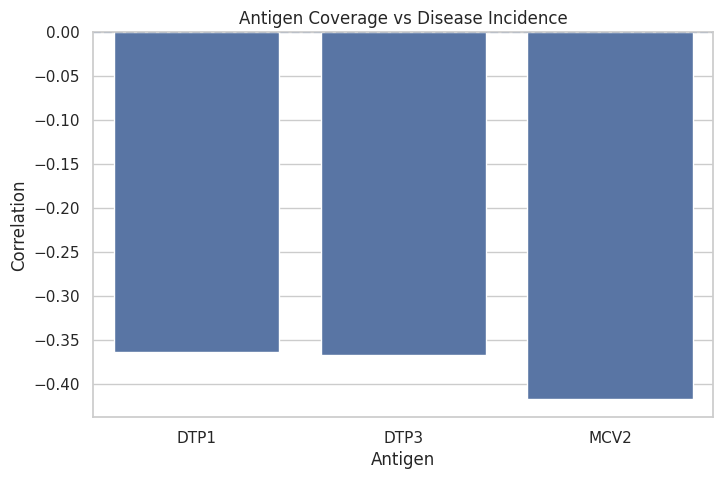

In [ ]:
# ============================================================
# MEDIUM Q7
# Antigen Coverage vs Disease Incidence
# ============================================================

antigen_results = []

for antigen in coverage["antigen"].unique():

    antigen_data = coverage[
        coverage["antigen"] == antigen
    ].groupby(
        ["country", "year"]
    )["coverage"].mean().reset_index()

    incidence_data = incidence.groupby(
        ["country", "year"]
    )["incidence_rate"].mean().reset_index()

    merged = pd.merge(
        antigen_data,
        incidence_data,
        on=["country", "year"],
        how="inner"
    )

    corr = merged["coverage"].corr(
        merged["incidence_rate"]
    )

    antigen_results.append([
        antigen,
        corr
    ])

q7_medium = pd.DataFrame(
    antigen_results,
    columns=["Antigen", "Correlation"]
)

print(q7_medium)

plt.figure(figsize=(8,5))
sns.barplot(
    data=q7_medium,
    x="Antigen",
    y="Correlation"
)
plt.title("Antigen Coverage vs Disease Incidence")
plt.xlabel("Antigen")
plt.ylabel("Correlation")
plt.axhline(0, linestyle="--")
plt.show()

Low coverage threshold: 81.86 %

Countries with relatively low coverage:
    country   coverage  vaccine_introductions
9  Thailand  81.788452                      5
2     Ghana  81.832698                      5
6     Nepal  81.859325                      5


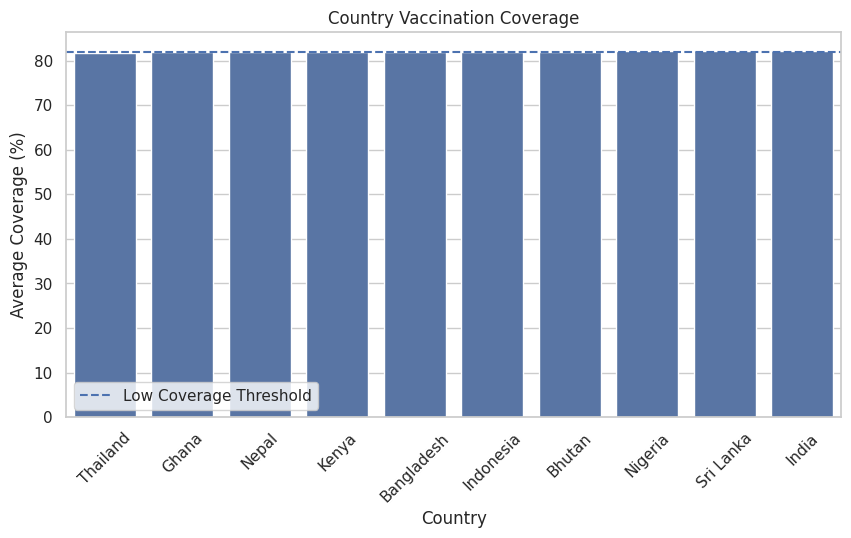

In [ ]:
# ============================================================
# MEDIUM Q8
# Low Coverage Despite Vaccine Introduction
# ============================================================

country_coverage = coverage.groupby(
    "country"
)["coverage"].mean().reset_index()

country_introduction = vaccine_intro.groupby(
    "country"
).size().reset_index(
    name="vaccine_introductions"
)

q8_medium = pd.merge(
    country_coverage,
    country_introduction,
    on="country",
    how="inner"
)

low_coverage_threshold = q8_medium["coverage"].quantile(0.25)

low_coverage_countries = q8_medium[
    q8_medium["coverage"] <= low_coverage_threshold
].sort_values("coverage")

print(
    "Low coverage threshold:",
    round(low_coverage_threshold, 2),
    "%"
)

print("\nCountries with relatively low coverage:")
print(low_coverage_countries)

plt.figure(figsize=(10,5))
sns.barplot(
    data=q8_medium.sort_values("coverage"),
    x="country",
    y="coverage"
)
plt.axhline(
    low_coverage_threshold,
    linestyle="--",
    label="Low Coverage Threshold"
)
plt.title("Country Vaccination Coverage")
plt.xlabel("Country")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

            Tuberculosis_Cases  Hepatitis_B_Cases
country                                          
Bangladesh          208.714286         129.428571
Bhutan              215.857143         113.571429
Ghana               246.428571         133.428571
India               134.142857          97.285714
Indonesia           198.571429         158.571429
Kenya               221.857143         111.285714
Nepal               204.714286         150.714286
Nigeria             220.571429         120.714286
Sri Lanka           211.571429         126.285714
Thailand            220.571429         137.857143


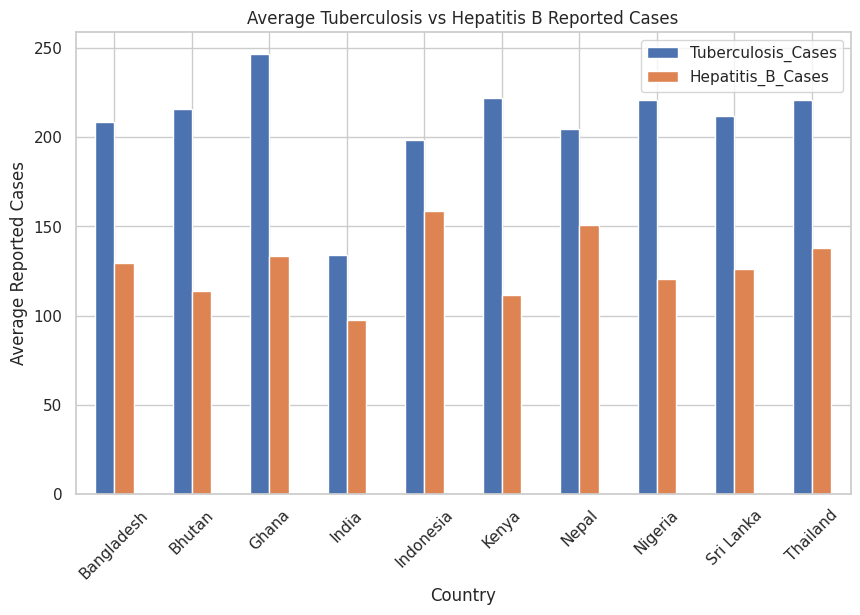

In [ ]:
# ============================================================
# MEDIUM Q9
# Tuberculosis vs Hepatitis B Comparison
# ============================================================

tb_cases = reported_cases[
    reported_cases["disease"] == "Tuberculosis"
].groupby("country")["cases"].mean()

hep_cases = reported_cases[
    reported_cases["disease"] == "Hepatitis B"
].groupby("country")["cases"].mean()

q9_medium = pd.DataFrame({
    "Tuberculosis_Cases": tb_cases,
    "Hepatitis_B_Cases": hep_cases
})

print(q9_medium)

q9_medium.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Tuberculosis vs Hepatitis B Reported Cases")
plt.xlabel("Country")
plt.ylabel("Average Reported Cases")
plt.xticks(rotation=45)
plt.show()

       country       disease  incidence_rate
39     Nigeria  Tuberculosis       37.508571
14       Ghana  Tuberculosis       37.172857
24   Indonesia  Tuberculosis       36.820000
29       Kenya  Tuberculosis       36.784286
9       Bhutan  Tuberculosis       36.450000
44   Sri Lanka  Tuberculosis       36.197143
34       Nepal  Tuberculosis       35.980000
19       India  Tuberculosis       35.688571
4   Bangladesh  Tuberculosis       35.642857
49    Thailand  Tuberculosis       35.634286
41   Sri Lanka     Influenza       34.074286
36     Nigeria     Influenza       33.867143
6       Bhutan     Influenza       33.775714
1   Bangladesh     Influenza       33.378571
11       Ghana     Influenza       32.941429


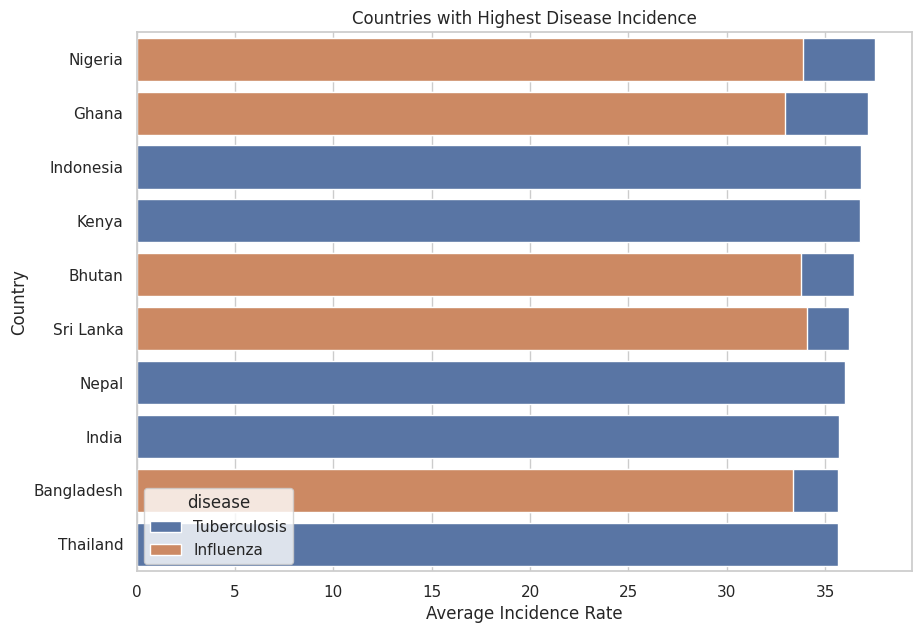

In [ ]:
# ============================================================
# MEDIUM Q10
# Geographic Disease Burden
# ============================================================

q10_medium = incidence.groupby(
    ["country", "disease"]
)["incidence_rate"].mean().reset_index()

top_burden = q10_medium.sort_values(
    "incidence_rate",
    ascending=False
).head(15)

print(top_burden)

plt.figure(figsize=(10,7))
sns.barplot(
    data=top_burden,
    x="incidence_rate",
    y="country",
    hue="disease",
    dodge=False
)

plt.title("Countries with Highest Disease Incidence")
plt.xlabel("Average Incidence Rate")
plt.ylabel("Country")
plt.show()

Low Coverage Threshold: 81.86 %

Countries requiring attention:
    country   coverage
9  Thailand  81.788452
2     Ghana  81.832698
6     Nepal  81.859325


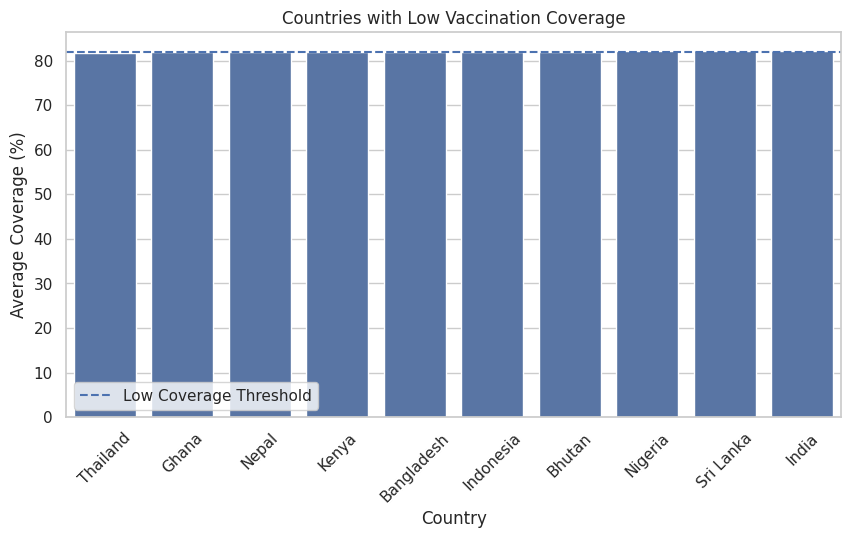

In [ ]:
# ============================================================
# SCENARIO Q1
# Identify countries with low vaccination coverage
# ============================================================

q1_scenario = coverage.groupby(
    "country"
)["coverage"].mean().reset_index()

low_threshold = q1_scenario["coverage"].quantile(0.25)

low_coverage = q1_scenario[
    q1_scenario["coverage"] <= low_threshold
].sort_values("coverage")

print("Low Coverage Threshold:",
      round(low_threshold, 2), "%")

print("\nCountries requiring attention:")
print(low_coverage)

plt.figure(figsize=(10,5))
sns.barplot(
    data=q1_scenario.sort_values("coverage"),
    x="country",
    y="coverage"
)

plt.axhline(
    low_threshold,
    linestyle="--",
    label="Low Coverage Threshold"
)

plt.title("Countries with Low Vaccination Coverage")
plt.xlabel("Country")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

High Incidence Threshold: 27.01

Countries with high measles incidence:
    country  incidence_rate
9  Thailand       28.028571
5     Kenya       27.117143
3     India       27.037143


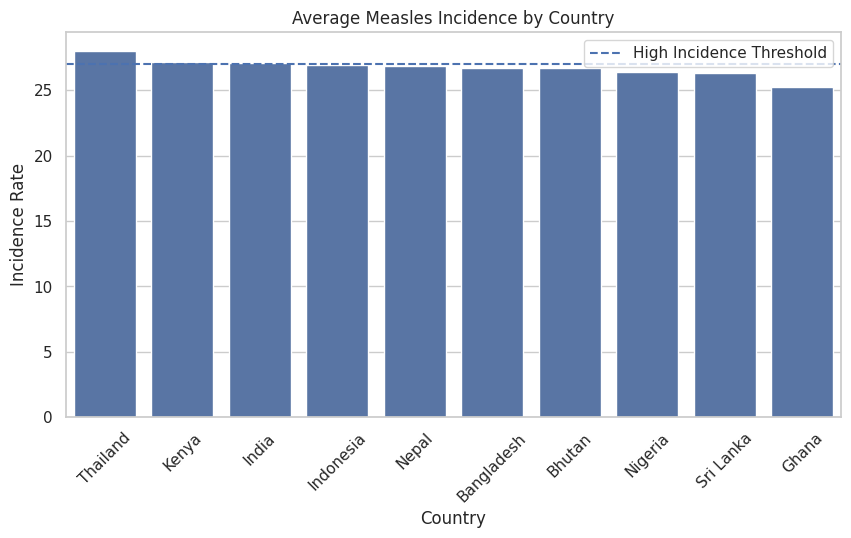

In [ ]:
# ============================================================
# SCENARIO Q2
# Identify countries with high measles incidence
# ============================================================

measles = incidence[
    incidence["disease"] == "Measles"
]

q2_scenario = measles.groupby(
    "country"
)["incidence_rate"].mean().reset_index()

high_threshold = q2_scenario[
    "incidence_rate"
].quantile(0.75)

high_measles = q2_scenario[
    q2_scenario["incidence_rate"] >= high_threshold
].sort_values(
    "incidence_rate",
    ascending=False
)

print("High Incidence Threshold:",
      round(high_threshold, 2))

print("\nCountries with high measles incidence:")
print(high_measles)

plt.figure(figsize=(10,5))
sns.barplot(
    data=q2_scenario.sort_values(
        "incidence_rate",
        ascending=False
    ),
    x="country",
    y="incidence_rate"
)

plt.axhline(
    high_threshold,
    linestyle="--",
    label="High Incidence Threshold"
)

plt.title("Average Measles Incidence by Country")
plt.xlabel("Country")
plt.ylabel("Incidence Rate")
plt.xticks(rotation=45)
plt.legend()
plt.show()

  antigen  target_number
1    DTP3      234338681
2    MCV2      232283935
0    DTP1      228430117


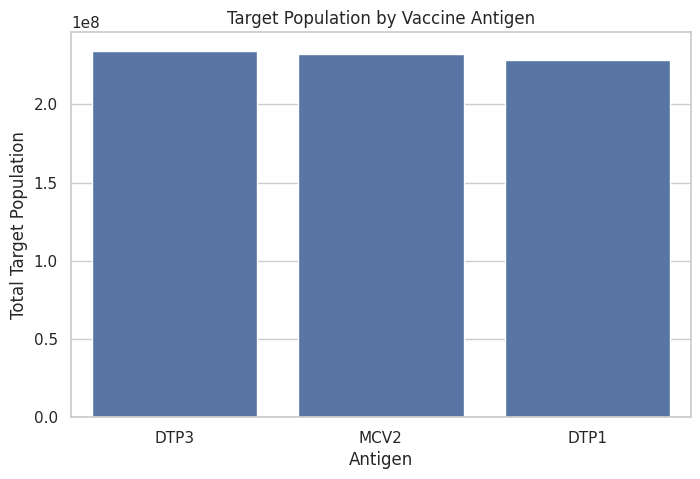

In [ ]:
# ============================================================
# SCENARIO Q3
# Identify vaccines with largest target populations
# ============================================================

q3_scenario = coverage.groupby(
    "antigen"
)["target_number"].sum().reset_index()

q3_scenario = q3_scenario.sort_values(
    "target_number",
    ascending=False
)

print(q3_scenario)

plt.figure(figsize=(8,5))
sns.barplot(
    data=q3_scenario,
    x="antigen",
    y="target_number"
)

plt.title("Target Population by Vaccine Antigen")
plt.xlabel("Antigen")
plt.ylabel("Total Target Population")
plt.show()

      country  incidence_rate
8   Sri Lanka       34.074286
7     Nigeria       33.867143
1      Bhutan       33.775714
0  Bangladesh       33.378571
2       Ghana       32.941429
4   Indonesia       32.780000
9    Thailand       32.382857
6       Nepal       32.122857
5       Kenya       31.887143
3       India       30.271429


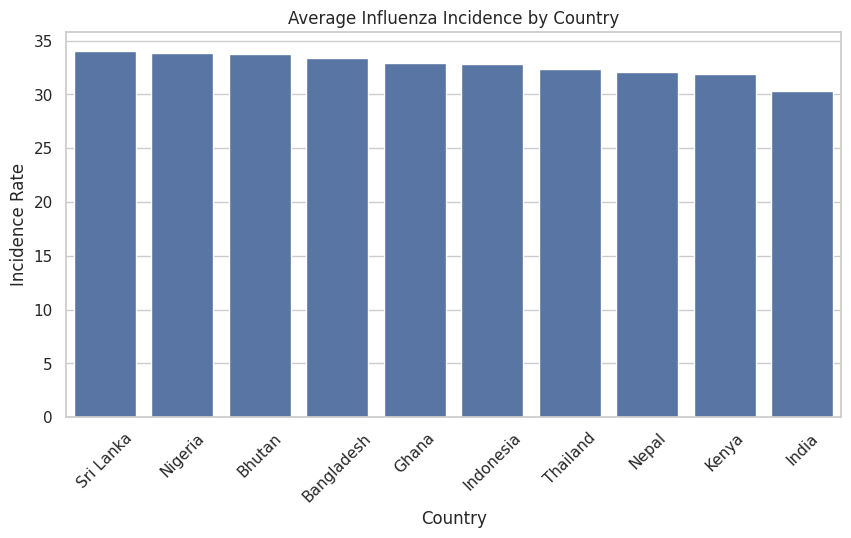

In [ ]:
# ============================================================
# SCENARIO Q4
# Influenza outbreak analysis
# ============================================================

influenza = incidence[
    incidence["disease"] == "Influenza"
]

q4_scenario = influenza.groupby(
    "country"
)["incidence_rate"].mean().reset_index()

q4_scenario = q4_scenario.sort_values(
    "incidence_rate",
    ascending=False
)

print(q4_scenario)

plt.figure(figsize=(10,5))
sns.barplot(
    data=q4_scenario,
    x="country",
    y="incidence_rate"
)

plt.title("Average Influenza Incidence by Country")
plt.xlabel("Country")
plt.ylabel("Incidence Rate")
plt.xticks(rotation=45)
plt.show()

      country      cases   coverage
6       Nepal  56.857143  81.859325
4   Indonesia  54.142857  81.988492
9    Thailand  53.142857  81.788452
2       Ghana  50.714286  81.832698
1      Bhutan  44.714286  82.036587
7     Nigeria  38.714286  82.079802
3       India  35.714286  82.258373
0  Bangladesh  32.000000  81.925516
8   Sri Lanka  31.428571  82.157183
5       Kenya  29.285714  81.865833


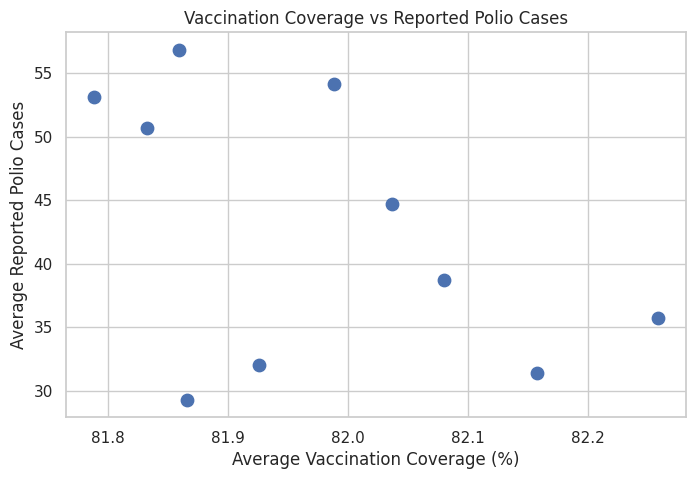

In [ ]:
# ============================================================
# SCENARIO Q5
# Polio cases vs DTP/MCV coverage
# ============================================================

polio = reported_cases[
    reported_cases["disease"] == "Polio"
].groupby(
    "country"
)["cases"].mean().reset_index()

country_coverage = coverage.groupby(
    "country"
)["coverage"].mean().reset_index()

q5_scenario = pd.merge(
    polio,
    country_coverage,
    on="country",
    how="inner"
)

print(q5_scenario.sort_values(
    "cases",
    ascending=False
))

plt.figure(figsize=(8,5))
plt.scatter(
    q5_scenario["coverage"],
    q5_scenario["cases"],
    s=80
)

plt.title("Vaccination Coverage vs Reported Polio Cases")
plt.xlabel("Average Vaccination Coverage (%)")
plt.ylabel("Average Reported Polio Cases")
plt.show()

95% Target Analysis
      country   coverage  gap_to_95
9    Thailand  81.788452  13.211548
2       Ghana  81.832698  13.167302
6       Nepal  81.859325  13.140675
5       Kenya  81.865833  13.134167
0  Bangladesh  81.925516  13.074484
4   Indonesia  81.988492  13.011508
1      Bhutan  82.036587  12.963413
7     Nigeria  82.079802  12.920198
8   Sri Lanka  82.157183  12.842817
3       India  82.258373  12.741627


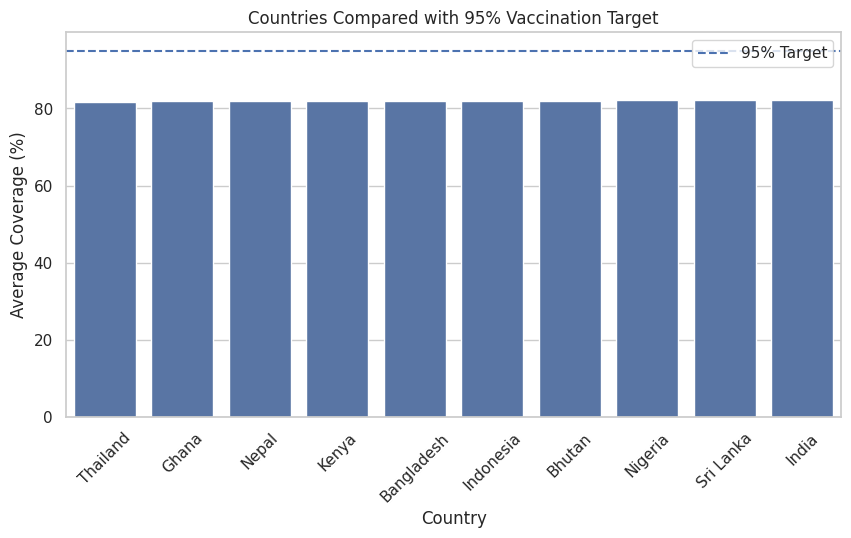

In [ ]:
# ============================================================
# SCENARIO Q6
# 95% Vaccination Target
# ============================================================

q6_scenario = coverage.groupby(
    "country"
)["coverage"].mean().reset_index()

target = 95

q6_scenario["gap_to_95"] = (
    target - q6_scenario["coverage"]
)

below_target = q6_scenario[
    q6_scenario["coverage"] < target
].sort_values(
    "coverage"
)

print("95% Target Analysis")
print(below_target)

plt.figure(figsize=(10,5))
sns.barplot(
    data=q6_scenario.sort_values("coverage"),
    x="country",
    y="coverage"
)

plt.axhline(
    95,
    linestyle="--",
    label="95% Target"
)

plt.title("Countries Compared with 95% Vaccination Target")
plt.xlabel("Country")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

Gender:
   gender   coverage
0  Female  81.757270
1    Male  82.201183

Education:
    education_level   coverage
0  Higher Education  82.550869
1     Primary/Below  81.295821
2         Secondary  82.090988

Residence:
  residence   coverage
0     Rural  81.398468
1     Urban  82.559984


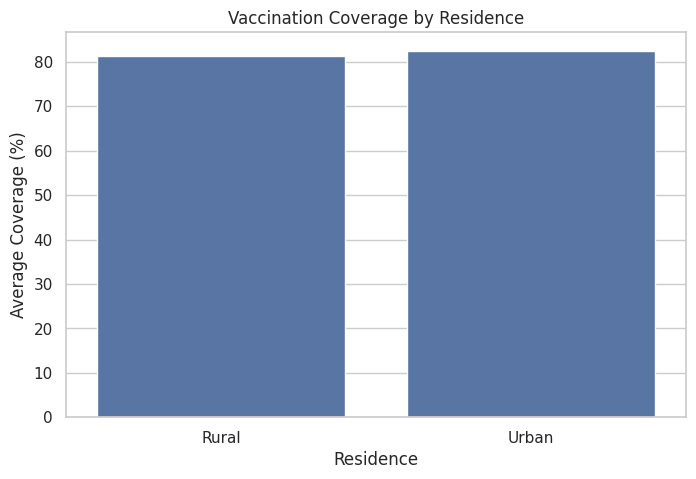

In [ ]:
# ============================================================
# SCENARIO Q7
# Identify demographic groups with lower coverage
# ============================================================

gender_analysis = coverage.groupby(
    "gender"
)["coverage"].mean().reset_index()

education_analysis = coverage.groupby(
    "education_level"
)["coverage"].mean().reset_index()

residence_analysis = coverage.groupby(
    "residence"
)["coverage"].mean().reset_index()

print("Gender:")
print(gender_analysis)

print("\nEducation:")
print(education_analysis)

print("\nResidence:")
print(residence_analysis)

plt.figure(figsize=(8,5))
sns.barplot(
    data=residence_analysis,
    x="residence",
    y="coverage"
)

plt.title("Vaccination Coverage by Residence")
plt.xlabel("Residence")
plt.ylabel("Average Coverage (%)")
plt.show()

    education_level  average_coverage    min    max
0  Higher Education         82.550869  72.26  94.51
1     Primary/Below         81.295821  71.67  92.05
2         Secondary         82.090988  71.53  92.64


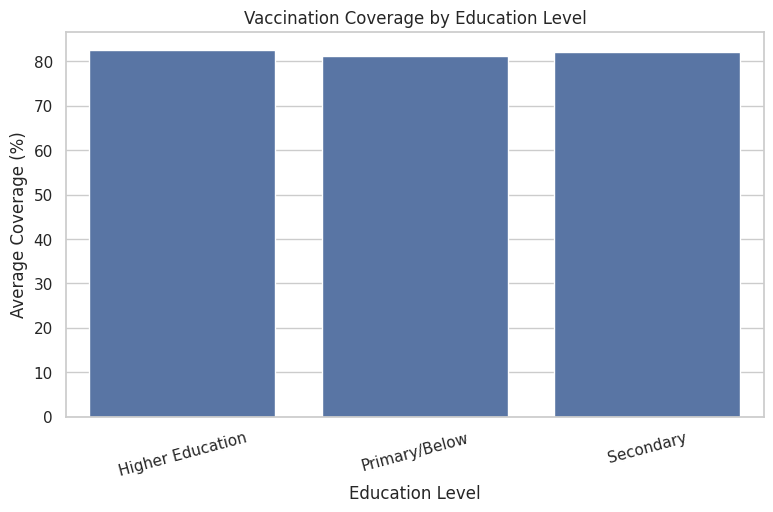

In [ ]:
# ============================================================
# SCENARIO Q8
# Education and Vaccination Coverage
# ============================================================

q8_scenario = coverage.groupby(
    "education_level"
)["coverage"].agg(
    ["mean", "min", "max"]
).reset_index()

q8_scenario.rename(
    columns={"mean": "average_coverage"},
    inplace=True
)

print(q8_scenario)

plt.figure(figsize=(9,5))
sns.barplot(
    data=q8_scenario,
    x="education_level",
    y="average_coverage"
)

plt.title("Vaccination Coverage by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Coverage (%)")
plt.xticks(rotation=15)
plt.show()

    month   coverage
0       1  81.937255
1       2  82.114208
2       3  81.724350
3       4  82.242683
4       5  81.862944
5       6  81.895612
6       7  82.372778
7       8  81.855693
8       9  82.087557
9      10  82.003158
10     11  81.887225
11     12  81.763548

Highest average coverage month: 7 with 82.37 %
Lowest average coverage month: 3 with 81.72 %


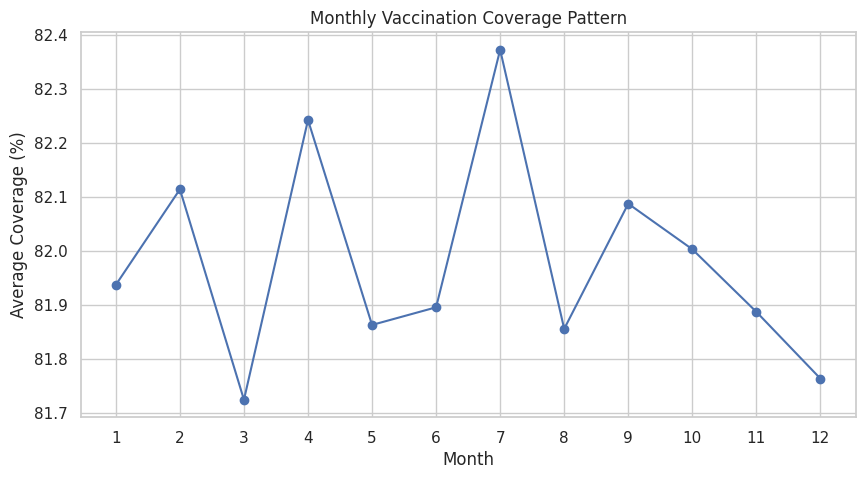

In [ ]:
# ============================================================
# SCENARIO Q9
# Monthly vaccination pattern
# ============================================================

q9_scenario = coverage.groupby(
    "month"
)["coverage"].mean().reset_index()

q9_scenario = q9_scenario.sort_values("month")

highest_month = q9_scenario.loc[
    q9_scenario["coverage"].idxmax()
]

lowest_month = q9_scenario.loc[
    q9_scenario["coverage"].idxmin()
]

print(q9_scenario)

print(
    "\nHighest average coverage month:",
    int(highest_month["month"]),
    "with",
    round(highest_month["coverage"], 2),
    "%"
)

print(
    "Lowest average coverage month:",
    int(lowest_month["month"]),
    "with",
    round(lowest_month["coverage"], 2),
    "%"
)

plt.figure(figsize=(10,5))
plt.plot(
    q9_scenario["month"],
    q9_scenario["coverage"],
    marker="o"
)

plt.title("Monthly Vaccination Coverage Pattern")
plt.xlabel("Month")
plt.ylabel("Average Coverage (%)")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

      country   coverage  incidence_rate
4   Indonesia  81.988492       25.804000
2       Ghana  81.832698       25.377429
9    Thailand  81.788452       25.351143
7     Nigeria  82.079802       25.317143
5       Kenya  81.865833       25.288286
6       Nepal  81.859325       24.962571
1      Bhutan  82.036587       24.874571
8   Sri Lanka  82.157183       24.736571
0  Bangladesh  81.925516       24.642857
3       India  82.258373       24.097143

Coverage vs incidence correlation: -0.597


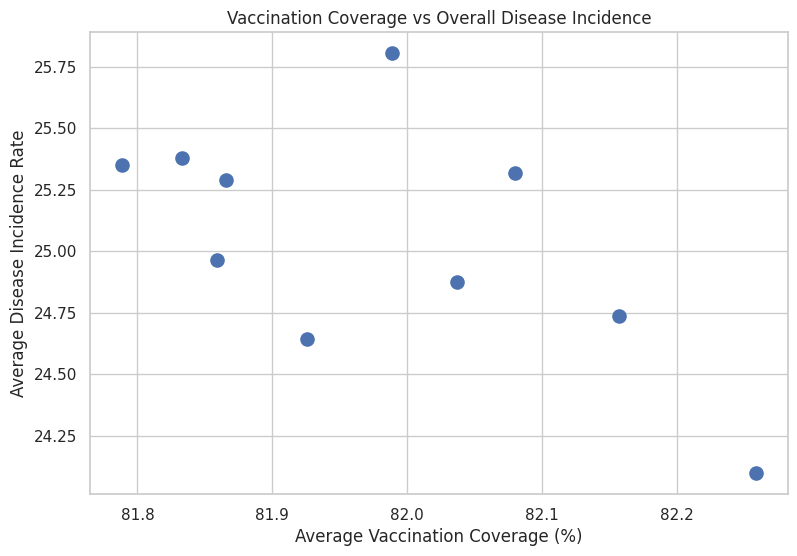

In [ ]:
# ============================================================
# SCENARIO Q10
# Coverage and Disease Incidence Together
# ============================================================

coverage_country = coverage.groupby(
    "country"
)["coverage"].mean().reset_index()

incidence_country = incidence.groupby(
    "country"
)["incidence_rate"].mean().reset_index()

q10_scenario = pd.merge(
    coverage_country,
    incidence_country,
    on="country",
    how="inner"
)

print(q10_scenario.sort_values(
    "incidence_rate",
    ascending=False
))

correlation = q10_scenario[
    "coverage"
].corr(
    q10_scenario["incidence_rate"]
)

print(
    "\nCoverage vs incidence correlation:",
    round(correlation, 3)
)

plt.figure(figsize=(9,6))
plt.scatter(
    q10_scenario["coverage"],
    q10_scenario["incidence_rate"],
    s=90
)

plt.title(
    "Vaccination Coverage vs Overall Disease Incidence"
)
plt.xlabel("Average Vaccination Coverage (%)")
plt.ylabel("Average Disease Incidence Rate")

plt.show()

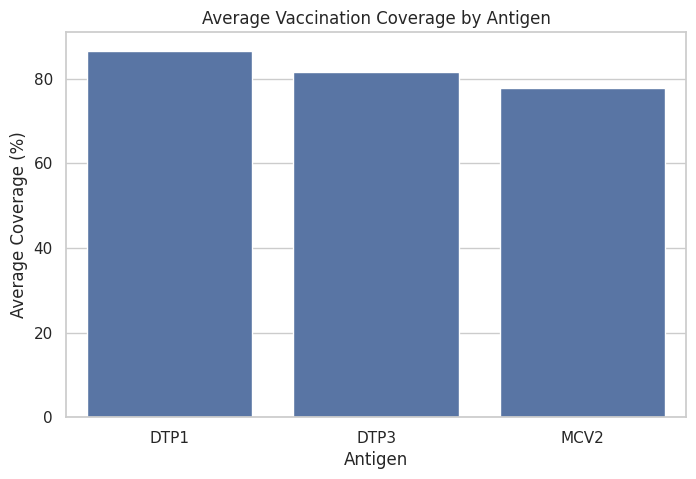

In [ ]:
# ============================================================
# GRAPH 1 — VACCINATION COVERAGE BY ANTIGEN
# ============================================================

graph1 = coverage.groupby(
    "antigen"
)["coverage"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=graph1,
    x="antigen",
    y="coverage"
)

plt.title("Average Vaccination Coverage by Antigen")
plt.xlabel("Antigen")
plt.ylabel("Average Coverage (%)")

plt.show()

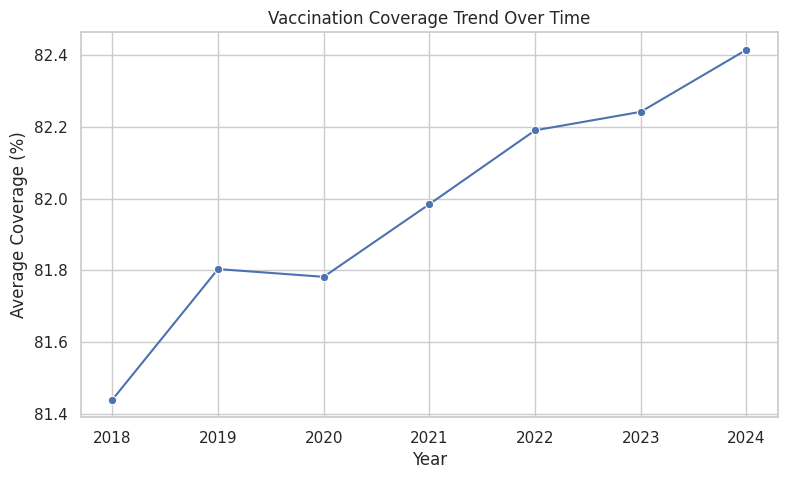

In [ ]:
# ============================================================
# GRAPH 2 — COVERAGE TREND
# ============================================================

graph2 = coverage.groupby(
    "year"
)["coverage"].mean().reset_index()

plt.figure(figsize=(9,5))

sns.lineplot(
    data=graph2,
    x="year",
    y="coverage",
    marker="o"
)

plt.title("Vaccination Coverage Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Coverage (%)")

plt.show()

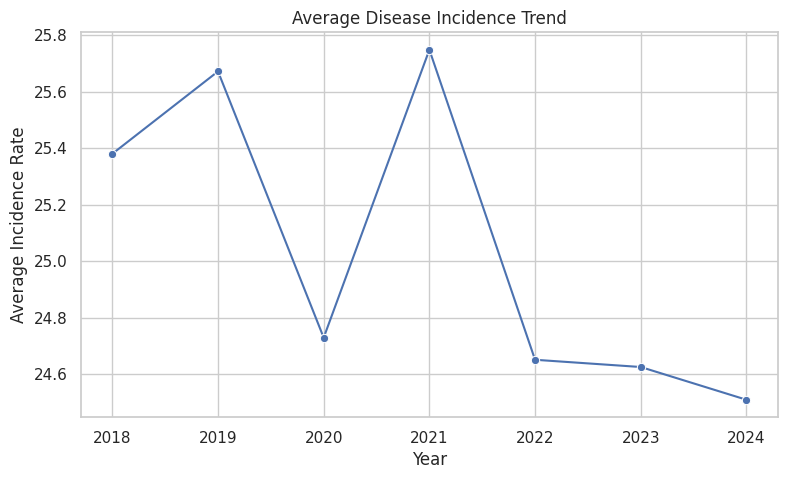

In [ ]:
# ============================================================
# GRAPH 3 — DISEASE INCIDENCE TREND
# ============================================================

graph3 = incidence.groupby(
    "year"
)["incidence_rate"].mean().reset_index()

plt.figure(figsize=(9,5))

sns.lineplot(
    data=graph3,
    x="year",
    y="incidence_rate",
    marker="o"
)

plt.title("Average Disease Incidence Trend")
plt.xlabel("Year")
plt.ylabel("Average Incidence Rate")

plt.show()

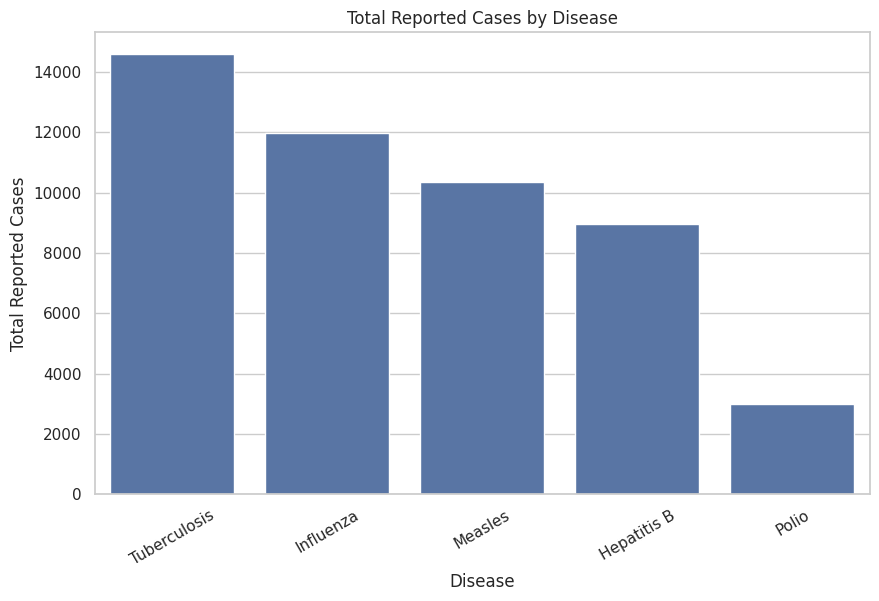

In [ ]:
# ============================================================
# GRAPH 4 — REPORTED CASES BY DISEASE
# ============================================================

graph4 = reported_cases.groupby(
    "disease"
)["cases"].sum().reset_index()

graph4 = graph4.sort_values(
    "cases",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=graph4,
    x="disease",
    y="cases"
)

plt.title("Total Reported Cases by Disease")
plt.xlabel("Disease")
plt.ylabel("Total Reported Cases")

plt.xticks(rotation=30)

plt.show()

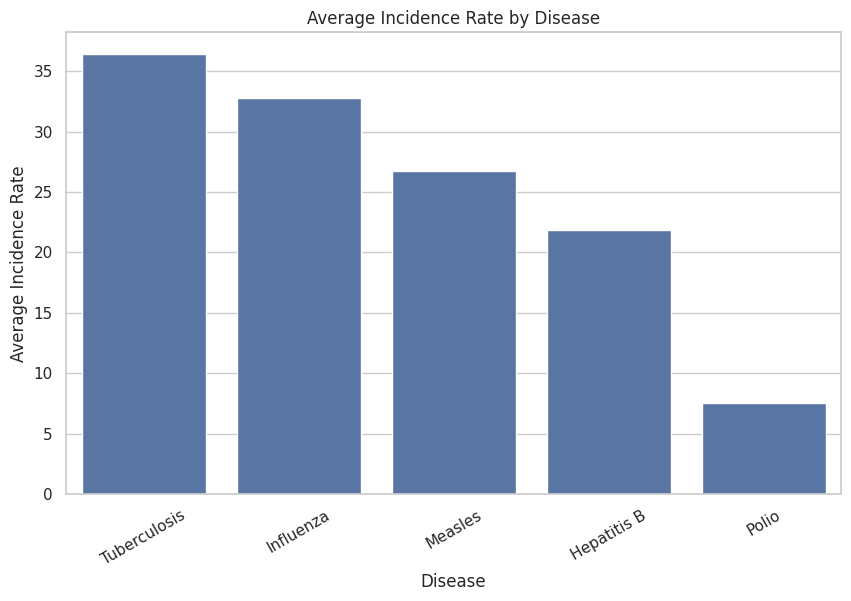

In [ ]:
# ============================================================
# GRAPH 5 — INCIDENCE BY DISEASE
# ============================================================

graph5 = incidence.groupby(
    "disease"
)["incidence_rate"].mean().reset_index()

graph5 = graph5.sort_values(
    "incidence_rate",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=graph5,
    x="disease",
    y="incidence_rate"
)

plt.title("Average Incidence Rate by Disease")
plt.xlabel("Disease")
plt.ylabel("Average Incidence Rate")

plt.xticks(rotation=30)

plt.show()

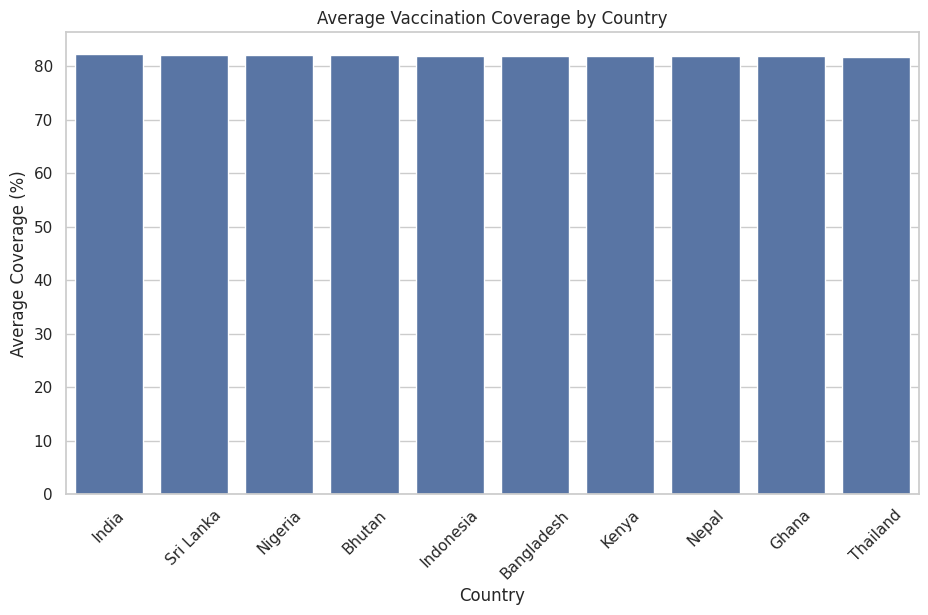

In [ ]:
# ============================================================
# GRAPH 6 — COUNTRY-WISE COVERAGE
# ============================================================

graph6 = coverage.groupby(
    "country"
)["coverage"].mean().reset_index()

graph6 = graph6.sort_values(
    "coverage",
    ascending=False
)

plt.figure(figsize=(11,6))

sns.barplot(
    data=graph6,
    x="country",
    y="coverage"
)

plt.title("Average Vaccination Coverage by Country")
plt.xlabel("Country")
plt.ylabel("Average Coverage (%)")

plt.xticks(rotation=45)

plt.show()

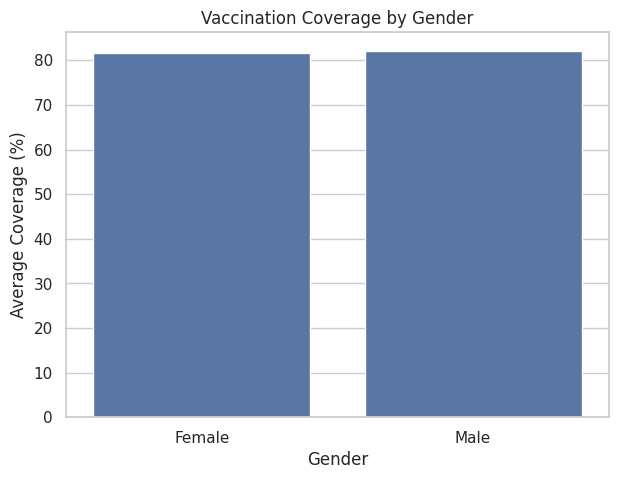

In [ ]:
# ============================================================
# GRAPH 7 — GENDER-WISE COVERAGE
# ============================================================

graph7 = coverage.groupby(
    "gender"
)["coverage"].mean().reset_index()

plt.figure(figsize=(7,5))

sns.barplot(
    data=graph7,
    x="gender",
    y="coverage"
)

plt.title("Vaccination Coverage by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Coverage (%)")

plt.show()

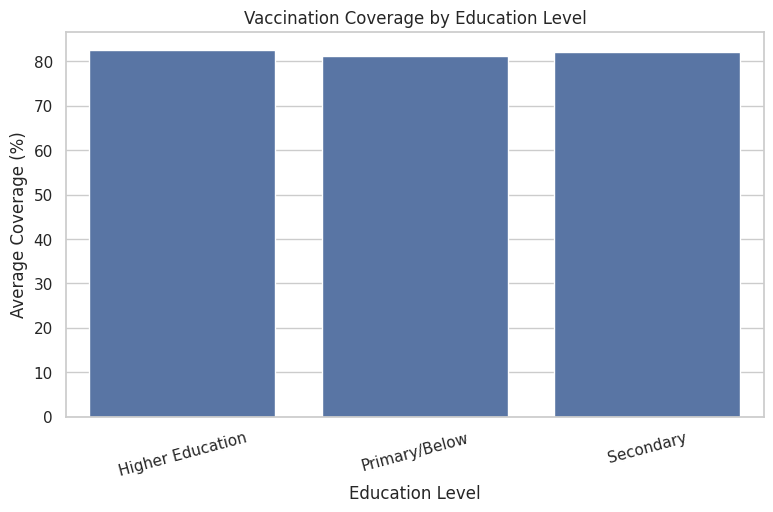

In [ ]:
# ============================================================
# GRAPH 8 — EDUCATION-WISE COVERAGE
# ============================================================

graph8 = coverage.groupby(
    "education_level"
)["coverage"].mean().reset_index()

plt.figure(figsize=(9,5))

sns.barplot(
    data=graph8,
    x="education_level",
    y="coverage"
)

plt.title("Vaccination Coverage by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Coverage (%)")

plt.xticks(rotation=15)

plt.show()

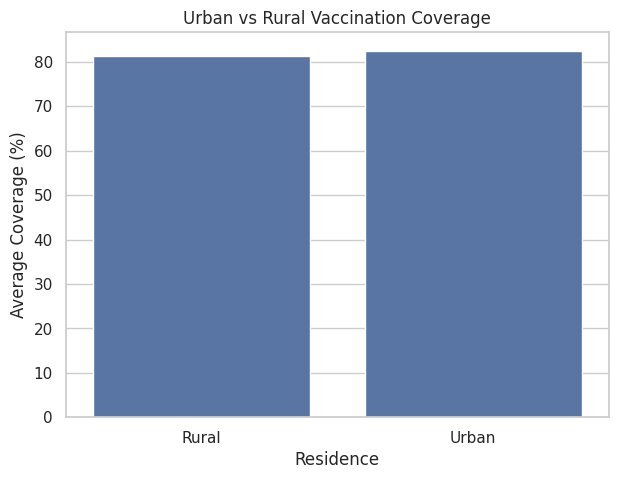

In [ ]:
# ============================================================
# GRAPH 9 — URBAN VS RURAL
# ============================================================

graph9 = coverage.groupby(
    "residence"
)["coverage"].mean().reset_index()

plt.figure(figsize=(7,5))

sns.barplot(
    data=graph9,
    x="residence",
    y="coverage"
)

plt.title("Urban vs Rural Vaccination Coverage")
plt.xlabel("Residence")
plt.ylabel("Average Coverage (%)")

plt.show()

Coverage vs Incidence Correlation: -0.525


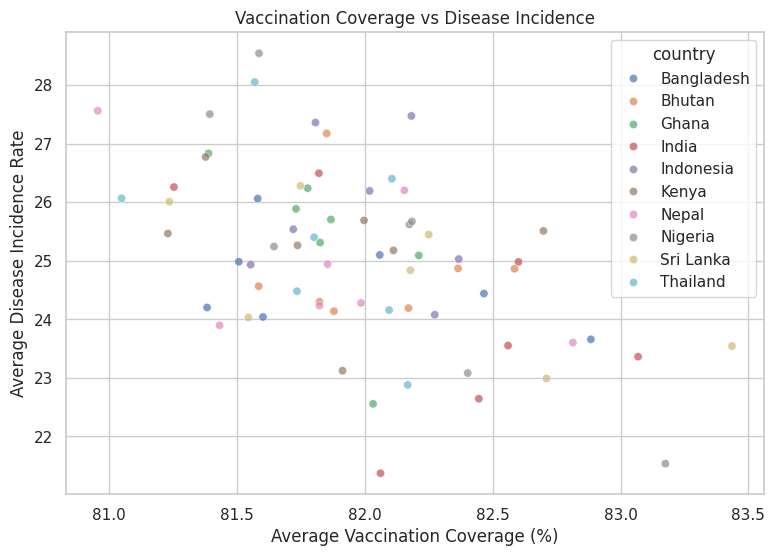

In [ ]:
# ============================================================
# GRAPH 10 — COVERAGE VS INCIDENCE
# ============================================================

coverage_country = coverage.groupby(
    ["country", "year"]
)["coverage"].mean().reset_index()

incidence_country = incidence.groupby(
    ["country", "year"]
)["incidence_rate"].mean().reset_index()

graph10 = pd.merge(
    coverage_country,
    incidence_country,
    on=["country", "year"],
    how="inner"
)

correlation = graph10[
    "coverage"
].corr(
    graph10["incidence_rate"]
)

print(
    "Coverage vs Incidence Correlation:",
    round(correlation, 3)
)

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=graph10,
    x="coverage",
    y="incidence_rate",
    hue="country",
    alpha=0.7
)

plt.title("Vaccination Coverage vs Disease Incidence")
plt.xlabel("Average Vaccination Coverage (%)")
plt.ylabel("Average Disease Incidence Rate")

plt.show()

Population Density vs Coverage Correlation: -0.004


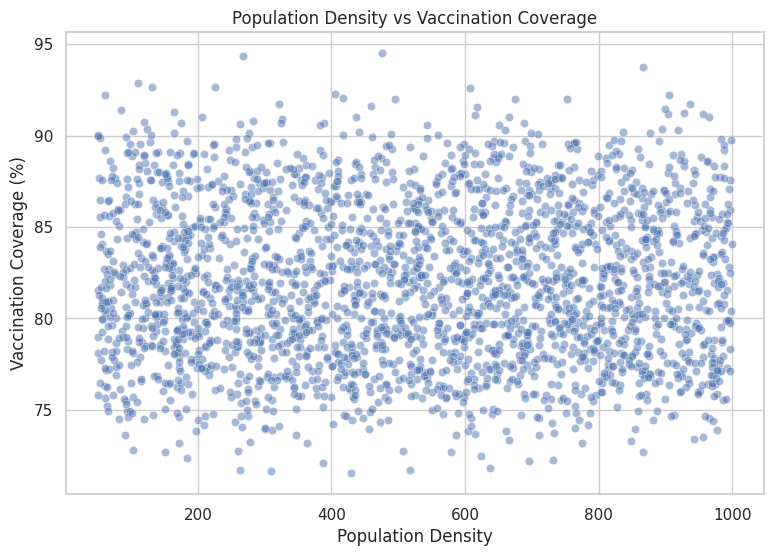

In [ ]:
# ============================================================
# GRAPH 11 — POPULATION DENSITY VS COVERAGE
# ============================================================

graph11 = coverage[
    ["population_density", "coverage"]
].dropna()

correlation_density = graph11[
    "population_density"
].corr(
    graph11["coverage"]
)

print(
    "Population Density vs Coverage Correlation:",
    round(correlation_density, 3)
)

plt.figure(figsize=(9,6))

sns.scatterplot(
    data=graph11,
    x="population_density",
    y="coverage",
    alpha=0.5
)

plt.title("Population Density vs Vaccination Coverage")
plt.xlabel("Population Density")
plt.ylabel("Vaccination Coverage (%)")

plt.show()

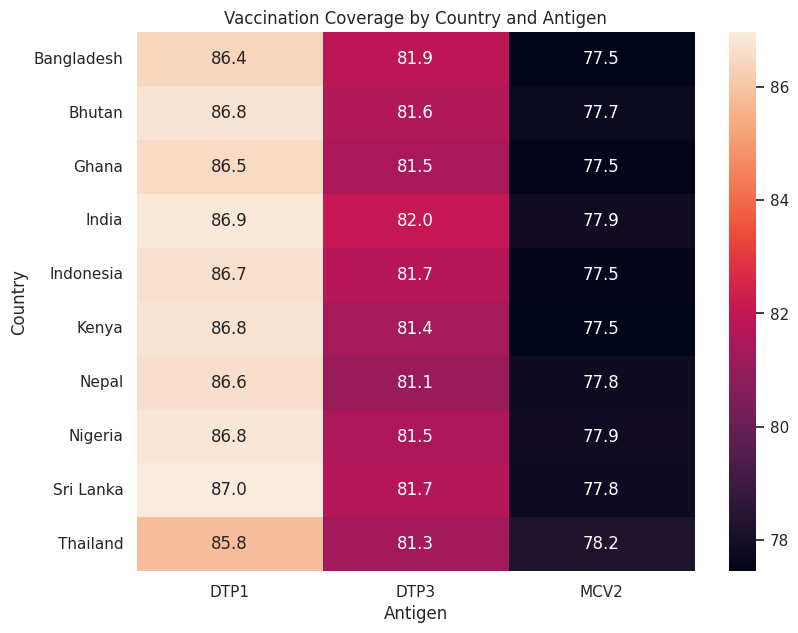

In [ ]:
# ============================================================
# GRAPH 12 — COUNTRY × ANTIGEN HEATMAP
# ============================================================

heatmap_data = coverage.pivot_table(
    index="country",
    columns="antigen",
    values="coverage",
    aggfunc="mean"
)

plt.figure(figsize=(9,7))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title("Vaccination Coverage by Country and Antigen")
plt.xlabel("Antigen")
plt.ylabel("Country")

plt.show()

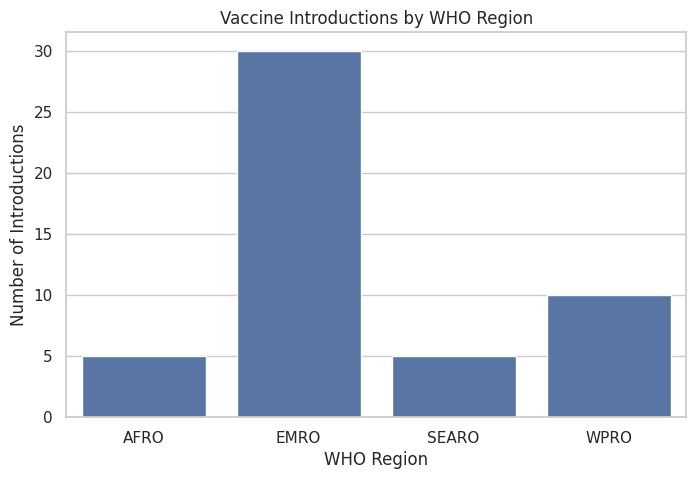

In [ ]:
# ============================================================
# GRAPH 13 — VACCINE INTRODUCTION BY WHO REGION
# ============================================================

graph13 = vaccine_intro.groupby(
    "WHO_region"
).size().reset_index(
    name="introductions"
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=graph13,
    x="WHO_region",
    y="introductions"
)

plt.title("Vaccine Introductions by WHO Region")
plt.xlabel("WHO Region")
plt.ylabel("Number of Introductions")

plt.show()

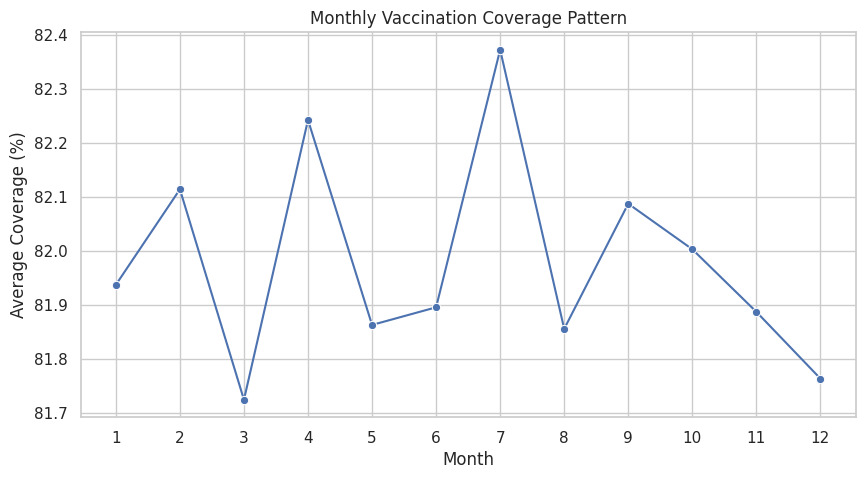

In [ ]:
# ============================================================
# GRAPH 14 — MONTHLY PATTERN
# ============================================================

graph14 = coverage.groupby(
    "month"
)["coverage"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=graph14,
    x="month",
    y="coverage",
    marker="o"
)

plt.title("Monthly Vaccination Coverage Pattern")
plt.xlabel("Month")
plt.ylabel("Average Coverage (%)")

plt.xticks(range(1,13))

plt.show()

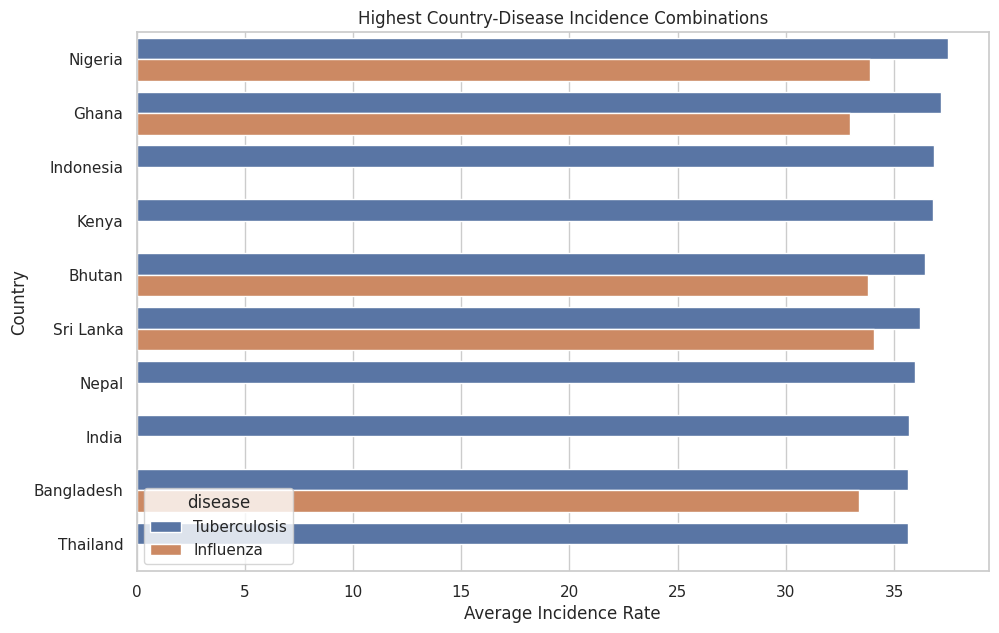

In [ ]:
# ============================================================
# GRAPH 15 — TOP COUNTRY-DISEASE COMBINATIONS
# ============================================================

graph15 = incidence.groupby(
    ["country", "disease"]
)["incidence_rate"].mean().reset_index()

graph15 = graph15.sort_values(
    "incidence_rate",
    ascending=False
).head(15)

plt.figure(figsize=(11,7))

sns.barplot(
    data=graph15,
    x="incidence_rate",
    y="country",
    hue="disease"
)

plt.title("Highest Country-Disease Incidence Combinations")
plt.xlabel("Average Incidence Rate")
plt.ylabel("Country")

plt.show()

In [ ]:
# ============================================================
# STEP 7 — SQL DATABASE SETUP
# ============================================================

import sqlite3
import pandas as pd

# Create SQLite database
conn = sqlite3.connect("vaccination_project.db")

# Send the five datasets into SQL tables
coverage.to_sql(
    "coverage",
    conn,
    if_exists="replace",
    index=False
)

incidence.to_sql(
    "incidence_rate",
    conn,
    if_exists="replace",
    index=False
)

reported_cases.to_sql(
    "reported_cases",
    conn,
    if_exists="replace",
    index=False
)

vaccine_intro.to_sql(
    "vaccine_introduction",
    conn,
    if_exists="replace",
    index=False
)

vaccine_schedule.to_sql(
    "vaccine_schedule",
    conn,
    if_exists="replace",
    index=False
)

print("SQL database created successfully! ✅")
print("\nTables created:")
print("1. coverage")
print("2. incidence_rate")
print("3. reported_cases")
print("4. vaccine_introduction")
print("5. vaccine_schedule")

SQL database created successfully! ✅

Tables created:
1. coverage
2. incidence_rate
3. reported_cases
4. vaccine_introduction
5. vaccine_schedule


In [ ]:
# ============================================================
# STEP 7 — SQL DATABASE + ALL SQL QUERIES
# VACCINATION PROJECT
# ============================================================

import sqlite3
import pandas as pd

# ============================================================
# 1. CREATE SQL DATABASE
# ============================================================

conn = sqlite3.connect("vaccination_project.db")

print("Creating SQL database...\n")

# Convert DataFrames into SQL tables
coverage.to_sql(
    "coverage",
    conn,
    if_exists="replace",
    index=False
)

incidence.to_sql(
    "incidence_rate",
    conn,
    if_exists="replace",
    index=False
)

reported_cases.to_sql(
    "reported_cases",
    conn,
    if_exists="replace",
    index=False
)

vaccine_intro.to_sql(
    "vaccine_introduction",
    conn,
    if_exists="replace",
    index=False
)

vaccine_schedule.to_sql(
    "vaccine_schedule",
    conn,
    if_exists="replace",
    index=False
)

print("SQL database created successfully! ✅")


# ============================================================
# 2. CHECK TABLES
# ============================================================

tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

print("\nSQL TABLES:")
print(tables)


# ============================================================
# 3. QUERY 1 — AVERAGE VACCINATION COVERAGE BY ANTIGEN
# ============================================================

query1 = """
SELECT
    antigen,
    ROUND(AVG(coverage), 2) AS average_coverage
FROM coverage
GROUP BY antigen
ORDER BY average_coverage DESC;
"""

result1 = pd.read_sql_query(query1, conn)

print("\n" + "="*60)
print("QUERY 1 — AVERAGE COVERAGE BY ANTIGEN")
print("="*60)
print(result1)


# ============================================================
# 4. QUERY 2 — COUNTRY-WISE COVERAGE
# ============================================================

query2 = """
SELECT
    country,
    ROUND(AVG(coverage), 2) AS average_coverage
FROM coverage
GROUP BY country
ORDER BY average_coverage DESC;
"""

result2 = pd.read_sql_query(query2, conn)

print("\n" + "="*60)
print("QUERY 2 — COUNTRY-WISE COVERAGE")
print("="*60)
print(result2)


# ============================================================
# 5. QUERY 3 — YEAR-WISE COVERAGE
# ============================================================

query3 = """
SELECT
    year,
    ROUND(AVG(coverage), 2) AS average_coverage
FROM coverage
GROUP BY year
ORDER BY year;
"""

result3 = pd.read_sql_query(query3, conn)

print("\n" + "="*60)
print("QUERY 3 — YEAR-WISE COVERAGE")
print("="*60)
print(result3)


# ============================================================
# 6. QUERY 4 — AVERAGE DISEASE INCIDENCE
# ============================================================

query4 = """
SELECT
    disease,
    ROUND(AVG(incidence_rate), 2) AS average_incidence
FROM incidence_rate
GROUP BY disease
ORDER BY average_incidence DESC;
"""

result4 = pd.read_sql_query(query4, conn)

print("\n" + "="*60)
print("QUERY 4 — DISEASE INCIDENCE")
print("="*60)
print(result4)


# ============================================================
# 7. QUERY 5 — TOTAL REPORTED CASES BY DISEASE
# ============================================================

query5 = """
SELECT
    disease,
    SUM(cases) AS total_cases
FROM reported_cases
GROUP BY disease
ORDER BY total_cases DESC;
"""

result5 = pd.read_sql_query(query5, conn)

print("\n" + "="*60)
print("QUERY 5 — TOTAL REPORTED CASES")
print("="*60)
print(result5)


# ============================================================
# 8. QUERY 6 — GENDER-WISE COVERAGE
# ============================================================

query6 = """
SELECT
    gender,
    ROUND(AVG(coverage), 2) AS average_coverage
FROM coverage
GROUP BY gender
ORDER BY average_coverage DESC;
"""

result6 = pd.read_sql_query(query6, conn)

print("\n" + "="*60)
print("QUERY 6 — GENDER COMPARISON")
print("="*60)
print(result6)


# ============================================================
# 9. QUERY 7 — EDUCATION-WISE COVERAGE
# ============================================================

query7 = """
SELECT
    education_level,
    ROUND(AVG(coverage), 2) AS average_coverage
FROM coverage
GROUP BY education_level
ORDER BY average_coverage DESC;
"""

result7 = pd.read_sql_query(query7, conn)

print("\n" + "="*60)
print("QUERY 7 — EDUCATION COMPARISON")
print("="*60)
print(result7)


# ============================================================
# 10. QUERY 8 — URBAN VS RURAL
# ============================================================

query8 = """
SELECT
    residence,
    ROUND(AVG(coverage), 2) AS average_coverage
FROM coverage
GROUP BY residence
ORDER BY average_coverage DESC;
"""

result8 = pd.read_sql_query(query8, conn)

print("\n" + "="*60)
print("QUERY 8 — URBAN VS RURAL")
print("="*60)
print(result8)


# ============================================================
# 11. QUERY 9 — HIGHEST DISEASE INCIDENCE
# ============================================================

query9 = """
SELECT
    country,
    disease,
    ROUND(AVG(incidence_rate), 2) AS average_incidence
FROM incidence_rate
GROUP BY country, disease
ORDER BY average_incidence DESC
LIMIT 10;
"""

result9 = pd.read_sql_query(query9, conn)

print("\n" + "="*60)
print("QUERY 9 — HIGHEST DISEASE INCIDENCE")
print("="*60)
print(result9)


# ============================================================
# 12. QUERY 10 — COVERAGE VS DISEASE INCIDENCE
# ============================================================

query10 = """
SELECT
    c.country,
    c.year,
    ROUND(AVG(c.coverage), 2) AS average_coverage,
    ROUND(AVG(i.incidence_rate), 2) AS average_incidence
FROM coverage c
JOIN incidence_rate i
    ON c.country = i.country
    AND c.year = i.year
GROUP BY c.country, c.year
ORDER BY average_coverage DESC;
"""

result10 = pd.read_sql_query(query10, conn)

print("\n" + "="*60)
print("QUERY 10 — COVERAGE VS INCIDENCE")
print("="*60)
print(result10.head(20))


# ============================================================
# 13. QUERY 11 — VACCINE INTRODUCTIONS BY WHO REGION
# ============================================================

query11 = """
SELECT
    WHO_region,
    COUNT(*) AS number_of_introductions
FROM vaccine_introduction
GROUP BY WHO_region
ORDER BY number_of_introductions DESC;
"""

result11 = pd.read_sql_query(query11, conn)

print("\n" + "="*60)
print("QUERY 11 — VACCINE INTRODUCTIONS BY WHO REGION")
print("="*60)
print(result11)


# ============================================================
# 14. QUERY 12 — VACCINE INTRODUCTIONS BY YEAR
# ============================================================

query12 = """
SELECT
    year,
    COUNT(*) AS number_of_introductions
FROM vaccine_introduction
GROUP BY year
ORDER BY year;
"""

result12 = pd.read_sql_query(query12, conn)

print("\n" + "="*60)
print("QUERY 12 — VACCINE INTRODUCTIONS BY YEAR")
print("="*60)
print(result12)


# ============================================================
# 15. QUERY 13 — VACCINATION SCHEDULE
# ============================================================

query13 = """
SELECT
    vaccine_code,
    target_population,
    geographical_area,
    age_administered,
    schedule_rounds
FROM vaccine_schedule
ORDER BY vaccine_code;
"""

result13 = pd.read_sql_query(query13, conn)

print("\n" + "="*60)
print("QUERY 13 — VACCINATION SCHEDULE")
print("="*60)
print(result13)


# ============================================================
# 16. QUERY 14 — COUNTRIES BELOW 95% TARGET
# ============================================================

query14 = """
SELECT
    country,
    ROUND(AVG(coverage), 2) AS average_coverage,
    ROUND(95 - AVG(coverage), 2) AS gap_to_95
FROM coverage
GROUP BY country
HAVING AVG(coverage) < 95
ORDER BY average_coverage;
"""

result14 = pd.read_sql_query(query14, conn)

print("\n" + "="*60)
print("QUERY 14 — COUNTRIES BELOW 95% TARGET")
print("="*60)
print(result14)


# ============================================================
# 17. QUERY 15 — MEASLES INCIDENCE BY COUNTRY
# ============================================================

query15 = """
SELECT
    country,
    ROUND(AVG(incidence_rate), 2) AS average_measles_incidence
FROM incidence_rate
WHERE disease = 'Measles'
GROUP BY country
ORDER BY average_measles_incidence DESC;
"""

result15 = pd.read_sql_query(query15, conn)

print("\n" + "="*60)
print("QUERY 15 — MEASLES INCIDENCE")
print("="*60)
print(result15)


# ============================================================
# 18. SAVE DATABASE
# ============================================================

conn.commit()

print("\n" + "="*60)
print("SQL DATABASE SAVED")
print("="*60)

print("vaccination_project.db")


# ============================================================
# 19. CREATE SQL SCHEMA FILE
# ============================================================

schema_sql = """

-- VACCINATION PROJECT DATABASE
-- Five main tables

CREATE TABLE coverage (
    country TEXT,
    code TEXT,
    country_name TEXT,
    year INTEGER,
    antigen TEXT,
    target_number INTEGER,
    doses INTEGER,
    coverage REAL,
    gender TEXT,
    education_level TEXT,
    residence TEXT,
    population_density REAL,
    month INTEGER
);

CREATE TABLE incidence_rate (
    country TEXT,
    code TEXT,
    country_name TEXT,
    year INTEGER,
    disease TEXT,
    disease_description TEXT,
    denominator INTEGER,
    incidence_rate REAL
);

CREATE TABLE reported_cases (
    country TEXT,
    code TEXT,
    country_name TEXT,
    year INTEGER,
    disease TEXT,
    disease_description TEXT,
    cases INTEGER
);

CREATE TABLE vaccine_introduction (
    country TEXT,
    code TEXT,
    country_name TEXT,
    WHO_region TEXT,
    year INTEGER,
    vaccine TEXT,
    intro TEXT
);

CREATE TABLE vaccine_schedule (
    country TEXT,
    code TEXT,
    country_name TEXT,
    WHO_region TEXT,
    year INTEGER,
    vaccine_code TEXT,
    schedule_rounds INTEGER,
    target_population TEXT,
    geographical_area TEXT,
    age_administered TEXT
);

"""

with open(
    "vaccination_schema.sql",
    "w"
) as file:
    file.write(schema_sql)

print("\nvaccination_schema.sql created successfully! ✅")

print("\n" + "="*60)
print("STEP 7 — SQL COMPLETED SUCCESSFULLY ✅")
print("="*60)

Creating SQL database...

SQL database created successfully! ✅

SQL TABLES:
                   name
0              coverage
1        incidence_rate
2        reported_cases
3  vaccine_introduction
4      vaccine_schedule

QUERY 1 — AVERAGE COVERAGE BY ANTIGEN
  antigen  average_coverage
0    DTP1             86.63
1    DTP3             81.59
2    MCV2             77.72

QUERY 2 — COUNTRY-WISE COVERAGE
      country  average_coverage
0       India             82.26
1   Sri Lanka             82.16
2     Nigeria             82.08
3      Bhutan             82.04
4   Indonesia             81.99
5  Bangladesh             81.93
6       Kenya             81.87
7       Nepal             81.86
8       Ghana             81.83
9    Thailand             81.79

QUERY 3 — YEAR-WISE COVERAGE
   year  average_coverage
0  2018             81.44
1  2019             81.80
2  2020             81.78
3  2021             81.98
4  2022             82.19
5  2023             82.24
6  2024             82.41

QUERY

In [ ]:
# ============================================================
# STEP 8 — POWER BI DATA PREPARATION
# VACCINATION PROJECT
# ============================================================

import os
import shutil
from google.colab import files

print("=" * 60)
print("STEP 8 — POWER BI PREPARATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. CHECK REQUIRED DATASETS
# ------------------------------------------------------------

required_files = [
    "coverage.csv",
    "incidence_rate.csv",
    "reported_cases.csv",
    "vaccine_introduction.csv",
    "vaccine_schedule.csv"
]

print("\nChecking required files...\n")

missing_files = []

for file in required_files:
    if os.path.exists(file):
        print("✅", file)
    else:
        print("❌", file, "NOT FOUND")
        missing_files.append(file)

if missing_files:
    print("\nSome files are missing.")
    print("Please run Step 1 first.")
else:
    print("\n✅ All five CSV files are available!")


# ------------------------------------------------------------
# 2. CREATE POWER BI FOLDER
# ------------------------------------------------------------

powerbi_folder = "PowerBI_Data"

if os.path.exists(powerbi_folder):
    shutil.rmtree(powerbi_folder)

os.makedirs(powerbi_folder)

print("\nPower BI folder created.")


# ------------------------------------------------------------
# 3. COPY ALL FIVE CSV FILES
# ------------------------------------------------------------

for file in required_files:

    source = file
    destination = os.path.join(powerbi_folder, file)

    shutil.copy(source, destination)

print("\n✅ All five datasets copied into PowerBI_Data folder.")


# ------------------------------------------------------------
# 4. CREATE POWER BI DATA DESCRIPTION FILE
# ------------------------------------------------------------

description = """
VACCINATION PROJECT — POWER BI DATA

This folder contains five datasets prepared for Power BI.

1. coverage.csv
Contains vaccination coverage information including:
country, year, antigen, doses, coverage,
gender, education level, residence and population density.

2. incidence_rate.csv
Contains disease incidence information including:
country, year, disease and incidence rate.

3. reported_cases.csv
Contains reported disease cases by:
country, year and disease.

4. vaccine_introduction.csv
Contains vaccine introduction information including:
country, WHO region, year and vaccine.

5. vaccine_schedule.csv
Contains vaccination schedule information including:
vaccine, target population, geographical area,
age administered and schedule rounds.

IMPORTANT DATA NOTE:
This project uses a synthetic dataset structured according
to the variables specified in the project brief.

The data are intended for academic demonstration and analysis
and should NOT be interpreted as official WHO statistics.
"""

with open(
    os.path.join(powerbi_folder, "README_POWERBI.txt"),
    "w"
) as f:
    f.write(description)

print("✅ Power BI README created.")


# ------------------------------------------------------------
# 5. CREATE ZIP FILE
# ------------------------------------------------------------

zip_file = "Vaccination_Project_PowerBI_Data"

shutil.make_archive(
    zip_file,
    "zip",
    powerbi_folder
)

print("\n✅ ZIP file created:")
print("Vaccination_Project_PowerBI_Data.zip")


# ------------------------------------------------------------
# 6. DISPLAY DATASET INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

import pandas as pd

for file in required_files:

    df = pd.read_csv(file)

    print("\n" + file)
    print("-" * 40)
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])

# ------------------------------------------------------------
# 7. FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STEP 8 POWER BI PREPARATION COMPLETED ✅")
print("=" * 60)

print("""
Next:

1. Download the ZIP file.
2. Extract the ZIP file on your computer.
3. Open Power BI Desktop.
4. Import the five CSV files.
5. Create the dashboard.

Your ZIP file will contain:

📁 PowerBI_Data
   ├── coverage.csv
   ├── incidence_rate.csv
   ├── reported_cases.csv
   ├── vaccine_introduction.csv
   ├── vaccine_schedule.csv
   └── README_POWERBI.txt
""")

# ------------------------------------------------------------
# 8. AUTOMATIC DOWNLOAD
# ------------------------------------------------------------

files.download("Vaccination_Project_PowerBI_Data.zip")

STEP 8 — POWER BI PREPARATION

Checking required files...

✅ coverage.csv
✅ incidence_rate.csv
✅ reported_cases.csv
✅ vaccine_introduction.csv
✅ vaccine_schedule.csv

✅ All five CSV files are available!

Power BI folder created.

✅ All five datasets copied into PowerBI_Data folder.
✅ Power BI README created.

✅ ZIP file created:
Vaccination_Project_PowerBI_Data.zip

DATASET INFORMATION

coverage.csv
----------------------------------------
Rows: 2520
Columns: 13

incidence_rate.csv
----------------------------------------
Rows: 350
Columns: 8

reported_cases.csv
----------------------------------------
Rows: 350
Columns: 7

vaccine_introduction.csv
----------------------------------------
Rows: 50
Columns: 7

vaccine_schedule.csv
----------------------------------------
Rows: 50
Columns: 10

STEP 8 POWER BI PREPARATION COMPLETED ✅

Next:

1. Download the ZIP file.
2. Extract the ZIP file on your computer.
3. Open Power BI Desktop.
4. Import the five CSV files.
5. Create the dashboard.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>